# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 53     |  |
| :-------------|:-------------|
| Ben Geertman| 6529100 |
| Jasper Bom| 6295835 |
| Victor Arets| 6437184 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Ben','Victor']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Kalibratie | 12:00 |
| Mijlpaal 2: Eerste Iteratie | 13:45 |
| Mijlpaal 3: Volgende Iteraties | 15:00 |
| Opruimen | 16:00 |
| groep aanwezig 1| 11:00 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 15:30-15:45 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [53]<br>
<img src="./IMG_7904.JPG" width="400">

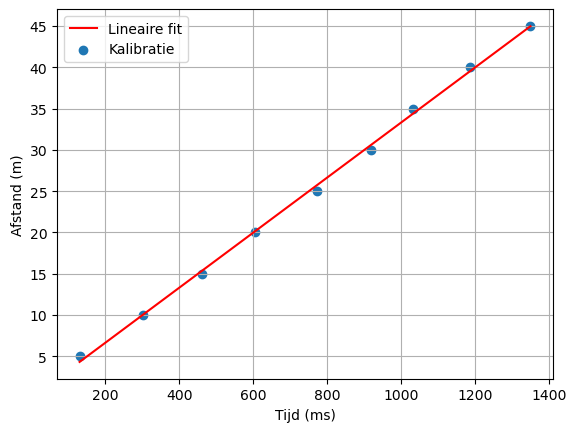

Alpha: 3.336e-02, Beta: -4.004e-02
0.033362008754534545 -0.04004101520907266


In [3]:
# verwerk hier jullie kalibratiemetingen

from scipy.optimize import curve_fit

afstand = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45]) # cm
tijd = np.array([131, 301, 462, 604, 772, 918, 1033, 1185, 1349])


def lin_func (x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin_func, tijd, afstand)

x_fit = np.linspace(min(tijd), max(tijd), 100)
y_fit = lin_func(x_fit, *popt)

plt.figure()
plt.grid()
plt.plot(x_fit, y_fit, color='red', label='Lineaire fit')
plt.scatter(tijd, afstand, label='Kalibratie')
plt.xlabel('Tijd (ms)')
plt.ylabel('Afstand (m)')
plt.legend()
plt.show()

print (f"Alpha: {popt[0]:.3e}, Beta: {popt[1]:.3e}")
print (popt[0], popt[1])

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  42
1   0  30   0  20  41
2  40   0  30   0  44
3  30   0  20   0  44


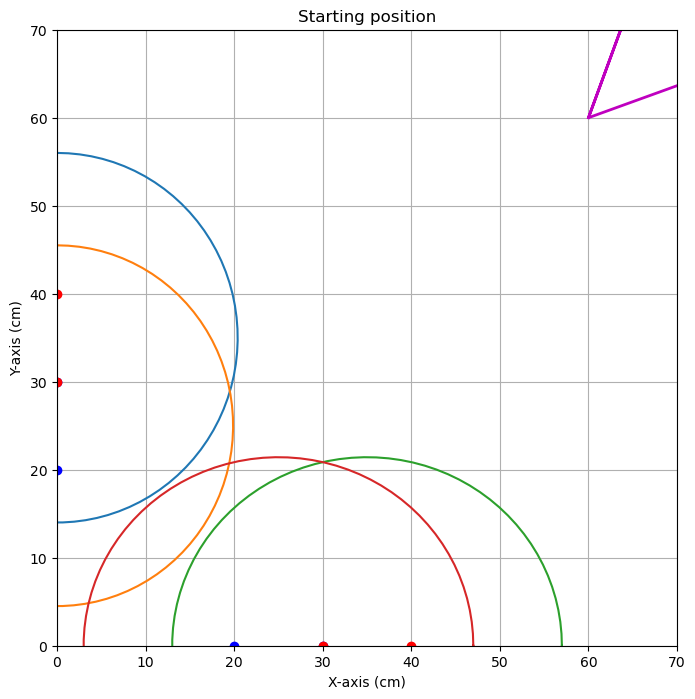


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.205


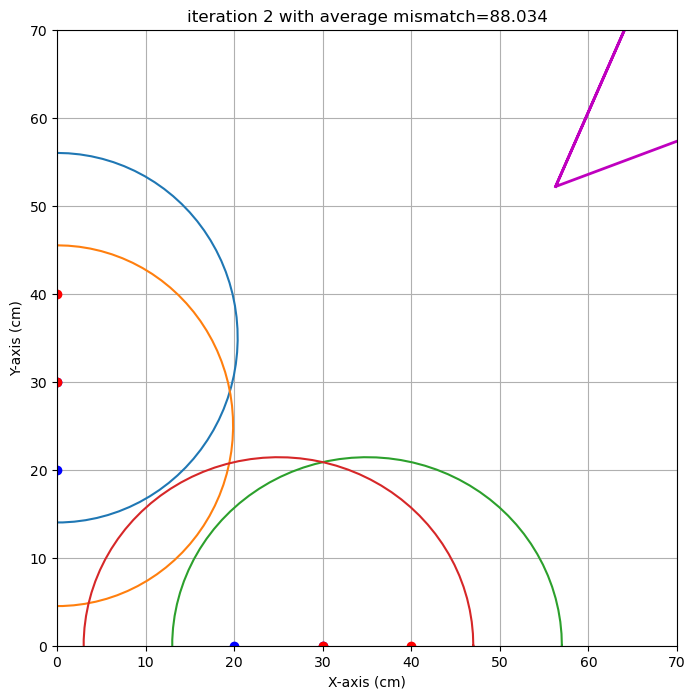

end iteration 2 with average mismatch=88.034


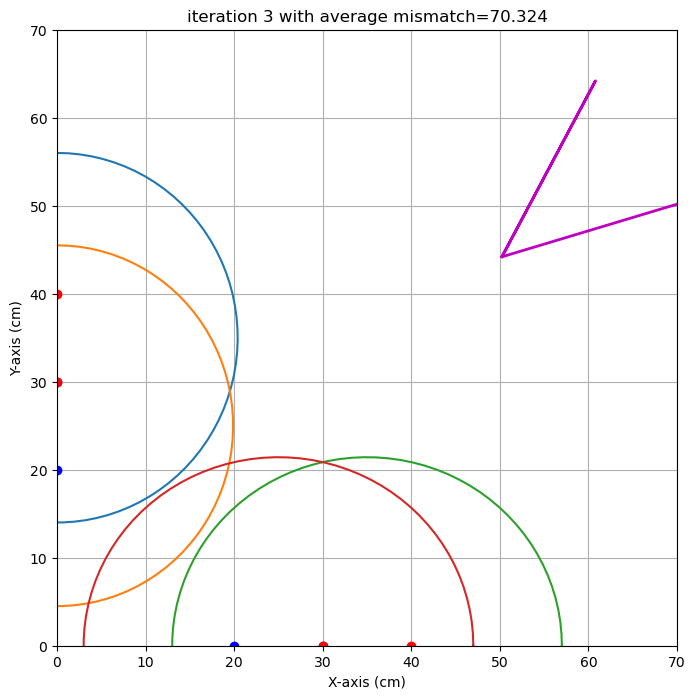

end iteration 3 with average mismatch=70.324


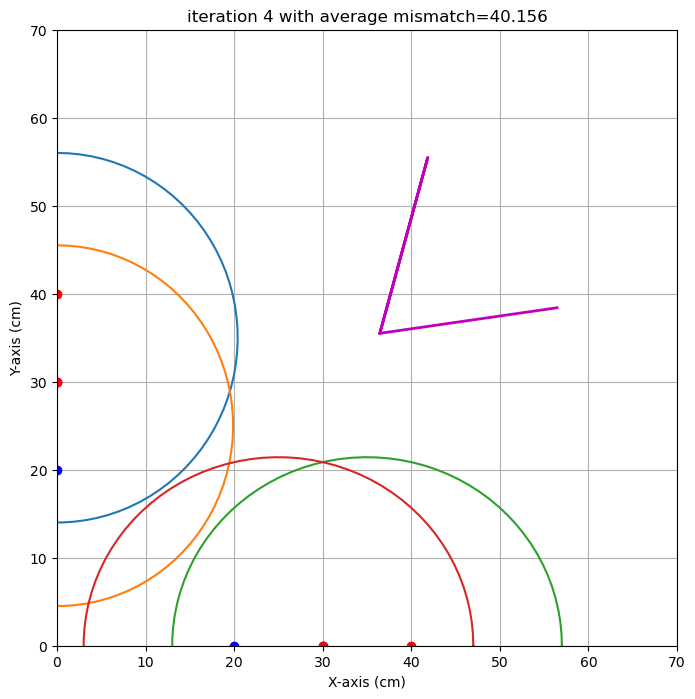

end iteration 4 with average mismatch=40.156


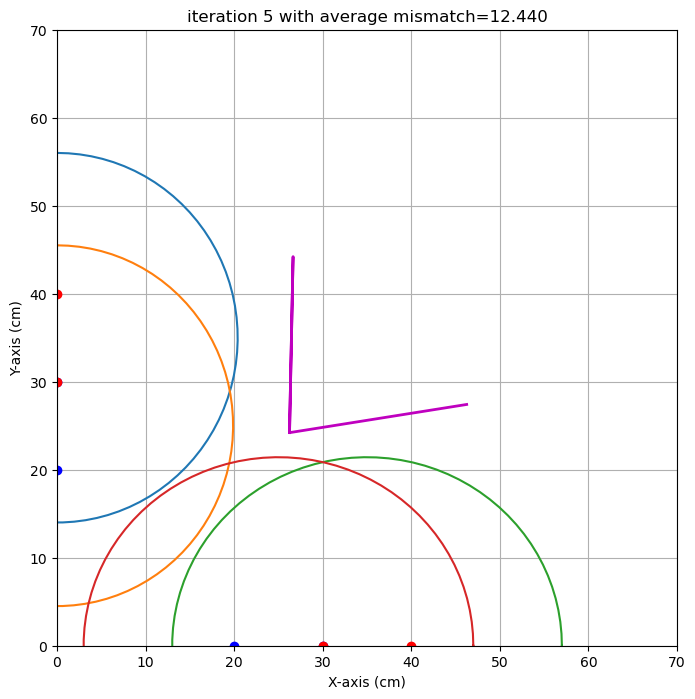

end iteration 5 with average mismatch=12.440


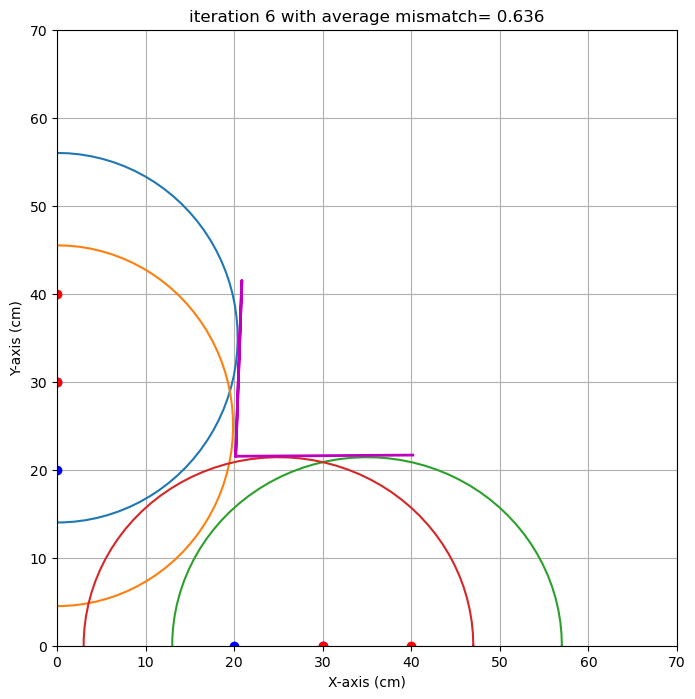

end iteration 6 with average mismatch= 0.636


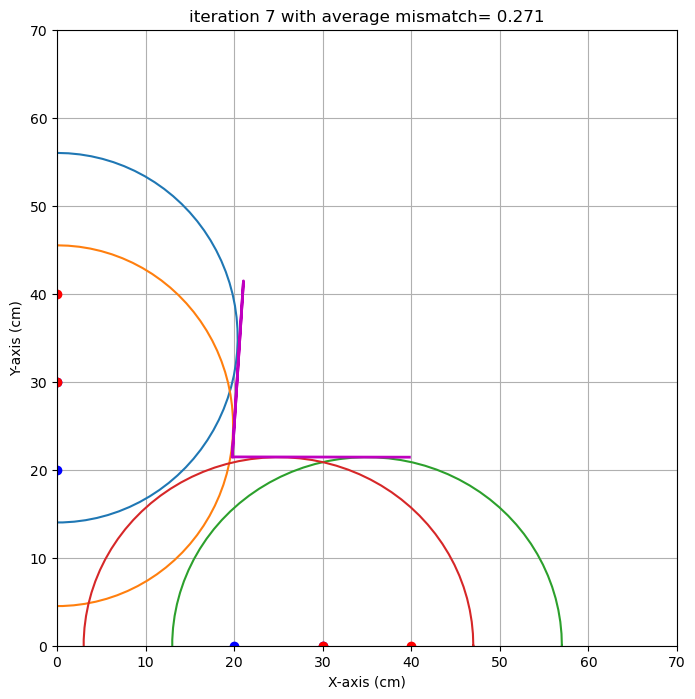

end iteration 7 with average mismatch= 0.271
end iteration 8 with average mismatch= 0.257
end iteration 9 with average mismatch= 0.256
end iteration 10 with average mismatch= 0.256
end iteration 11 with average mismatch= 0.256
end iteration 12 with average mismatch= 0.256
end iteration 13 with average mismatch= 0.256
end iteration 14 with average mismatch= 0.256
end iteration 15 with average mismatch= 0.256
end iteration 16 with average mismatch= 0.256
end iteration 17 with average mismatch= 0.256
end iteration 18 with average mismatch= 0.256
end iteration 19 with average mismatch= 0.256
end iteration 20 with average mismatch= 0.256
end iteration 21 with average mismatch= 0.256
end iteration 22 with average mismatch= 0.256
end iteration 23 with average mismatch= 0.256
end iteration 24 with average mismatch= 0.256
end iteration 25 with average mismatch= 0.256
end iteration 26 with average mismatch= 0.256
end iteration 27 with average mismatch= 0.256
end iteration 28 with average mismatc

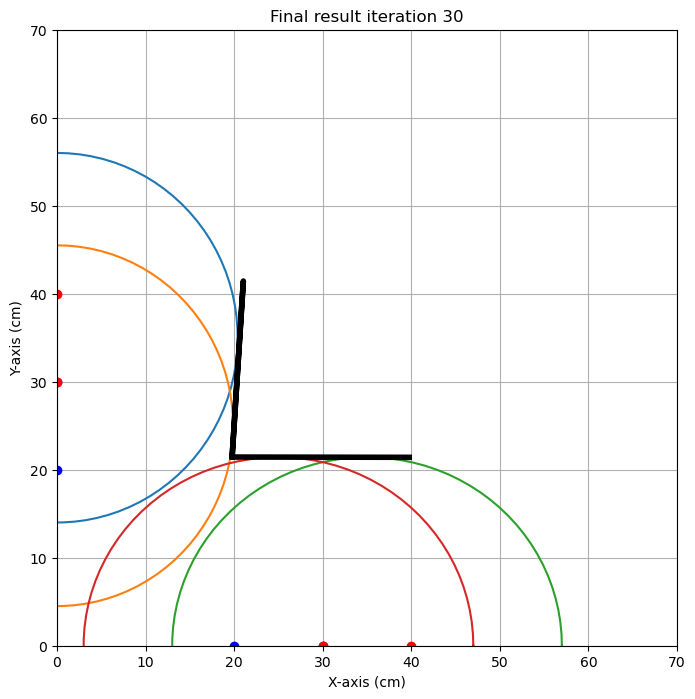

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42],
    [0,30,0,20,41],
    # [0,10,0,20,óngeldige meting],
    [40,0,30,0,44],
    [30,0,20,0,44],
   # [10,0,20,0,ongeldige meting],
   # [10,0,0,10,ongeldige meting]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.8 cm met een standaardafwijking van 0.0 cm 
y0: 21.4 cm met een standaardafwijking van 0.0 cm 
alpha: -0.1 graden met een standaardafwijking van 0.0 graad 
beta: 3.6 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Ben Geertman]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="./IMG_7905.JPG" width="400"><br>
Variatie B:<br>
<img src="./IMG_7908.JPG" width="400">

#### algoritme [Victor Arets]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="./IMG_7906.JPG" width="400"><br>
Variatie B:<br>
<img src="./IMG_7909.JPG" width="400">

#### algoritme [Jasper Bom]
Voeg een foto in van het algoritme van het derde groepslid
<img src="./IMG_7907.JPG" width="400"><br>
Variatie B:<br>
<img src="./IMG_7910.JPG" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 17,  #zelf aanvullen,
           'y0': 18,#zelf aanvullen,
           'alpha' : 10, #zelf aanvullen,
           'beta' : 15 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={
  'Ben' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [25, 0, 15, 0, 50],
      [30,0, 20, 0, 46],
      # [0, 25, 0, 15, niet geldig]
      [0, 45, 0, 35, 49],
      [0, 50, 0, 40, 50],
      
      
    ]),
    'Victor' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [30, 0, 40, 0, 50],
      [20, 0, 30, 0, 46],
      [0, 40, 0, 30, 41],
      [0, 30, 0, 20, 37],
    ])
}

## Opdracht 7: Evaluatie.

Ben
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  25   0  15   0  50
1  30   0  20   0  46
2   0  45   0  35  49
3   0  50   0  40  50


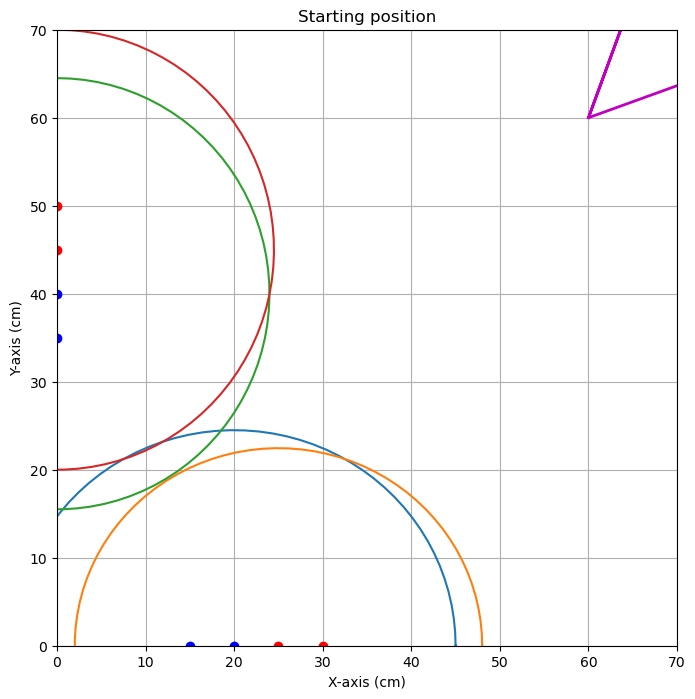


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=91.233


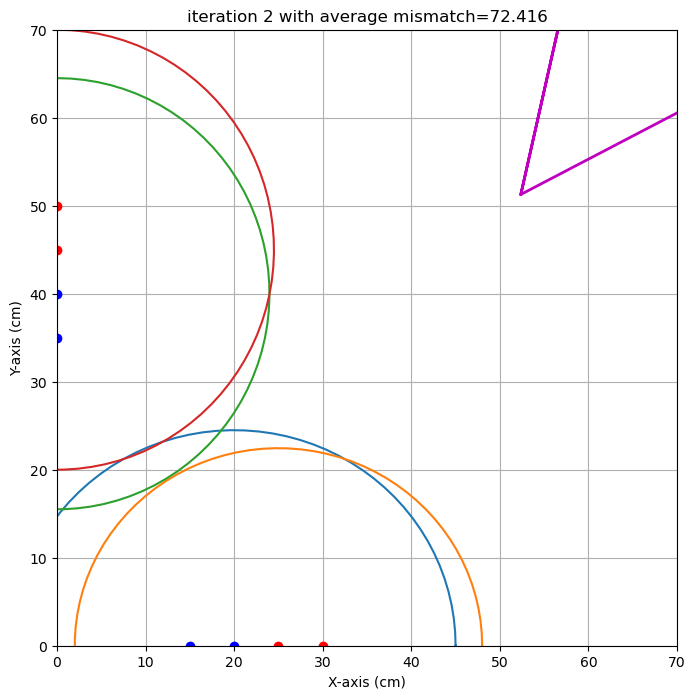

end iteration 2 with average mismatch=72.416


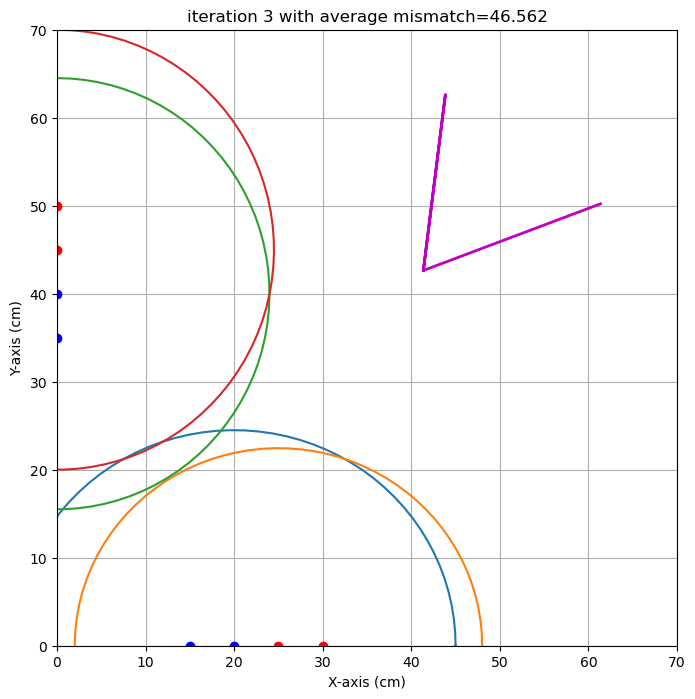

end iteration 3 with average mismatch=46.562


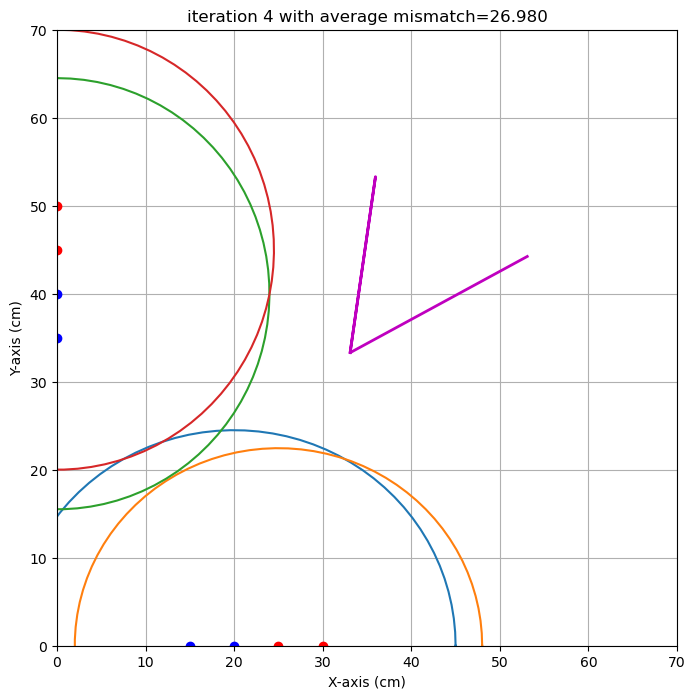

end iteration 4 with average mismatch=26.980


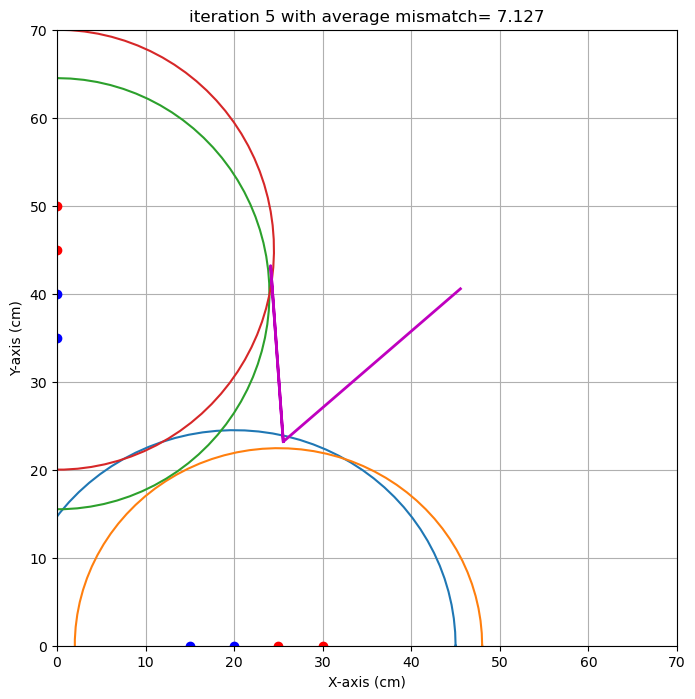

end iteration 5 with average mismatch= 7.127
end iteration 6 with average mismatch= 6.879


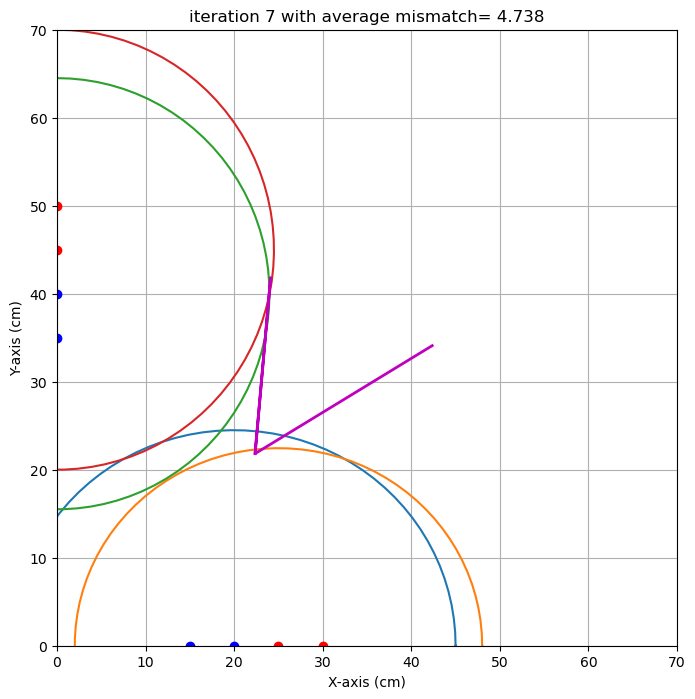

end iteration 7 with average mismatch= 4.738
end iteration 8 with average mismatch= 4.476
end iteration 9 with average mismatch= 4.476
end iteration 10 with average mismatch= 4.476


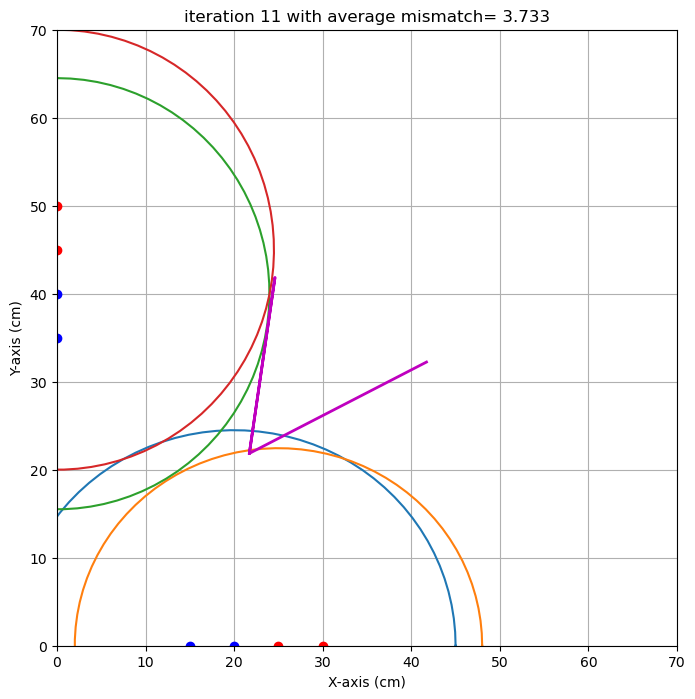

end iteration 11 with average mismatch= 3.733


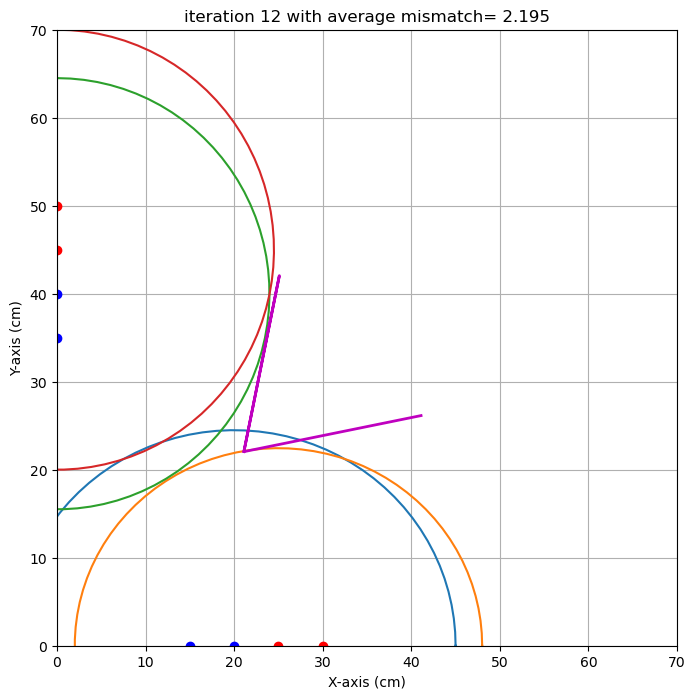

end iteration 12 with average mismatch= 2.195


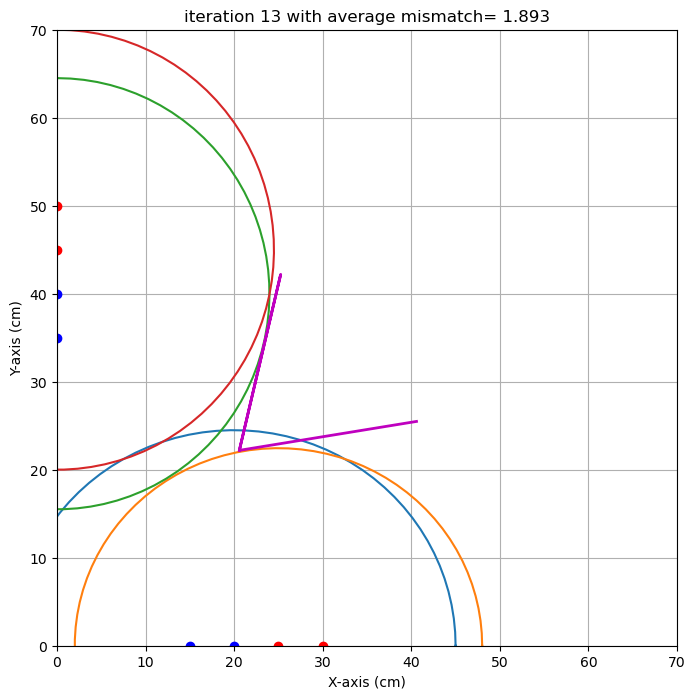

end iteration 13 with average mismatch= 1.893
end iteration 14 with average mismatch= 1.799
end iteration 15 with average mismatch= 1.688
end iteration 16 with average mismatch= 1.649
end iteration 17 with average mismatch= 1.642
end iteration 18 with average mismatch= 1.642
end iteration 19 with average mismatch= 1.642
end iteration 20 with average mismatch= 1.642
end iteration 21 with average mismatch= 1.642
end iteration 22 with average mismatch= 1.642
end iteration 23 with average mismatch= 1.621


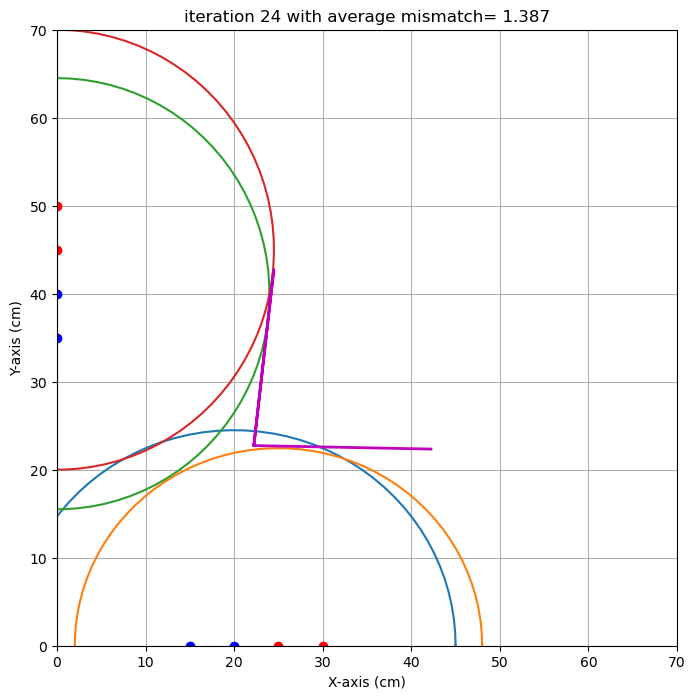

end iteration 24 with average mismatch= 1.387


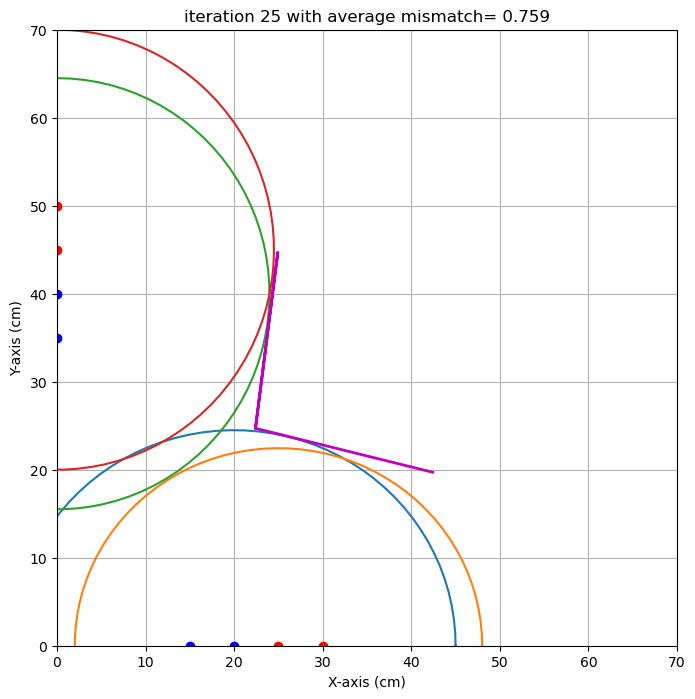

end iteration 25 with average mismatch= 0.759


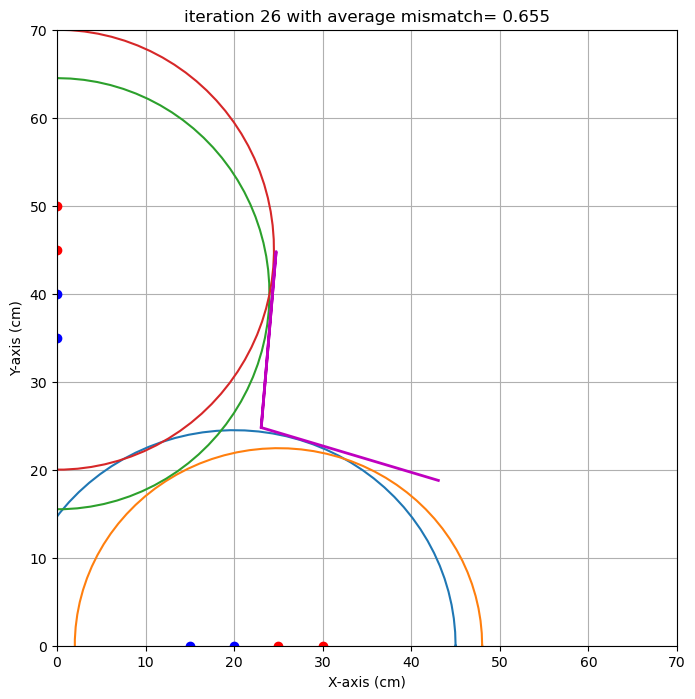

end iteration 26 with average mismatch= 0.655


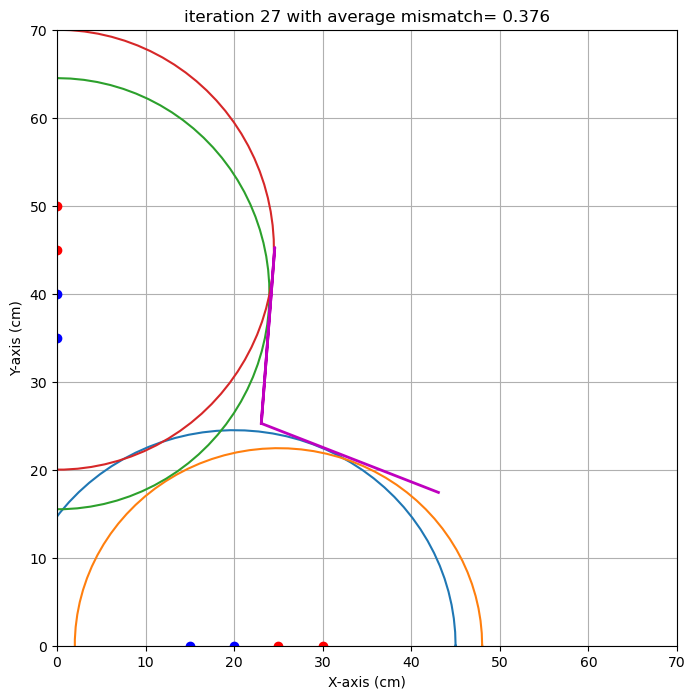

end iteration 27 with average mismatch= 0.376
end iteration 28 with average mismatch= 0.375
end iteration 29 with average mismatch= 0.347
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


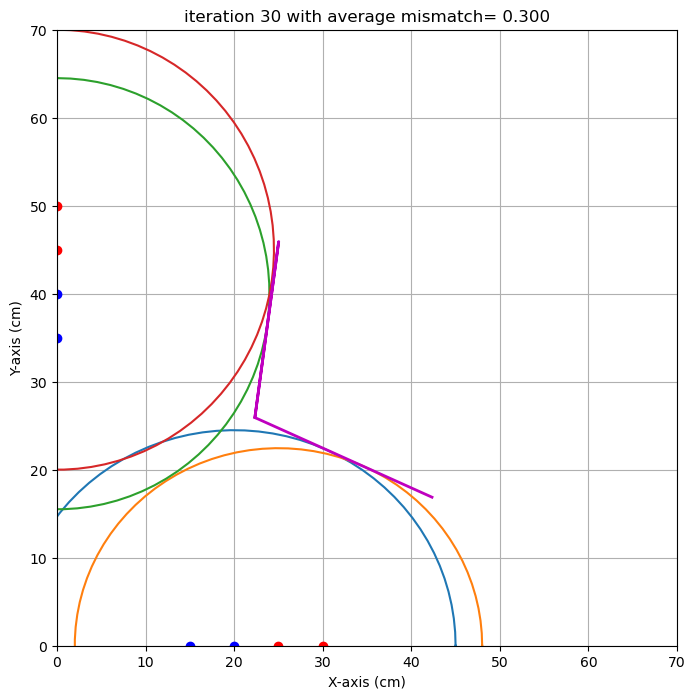

end iteration 30 with average mismatch= 0.300
###############################################################################
end of iteration  30
Best alpha= -24.35 with uncertainty=   0.00
Best beta =   7.66 with uncertainty=   0.00
Best x0   =  22.34 with uncertainty=   0.00
Best y0   =  25.93 with uncertainty=   0.00
###############################################################################


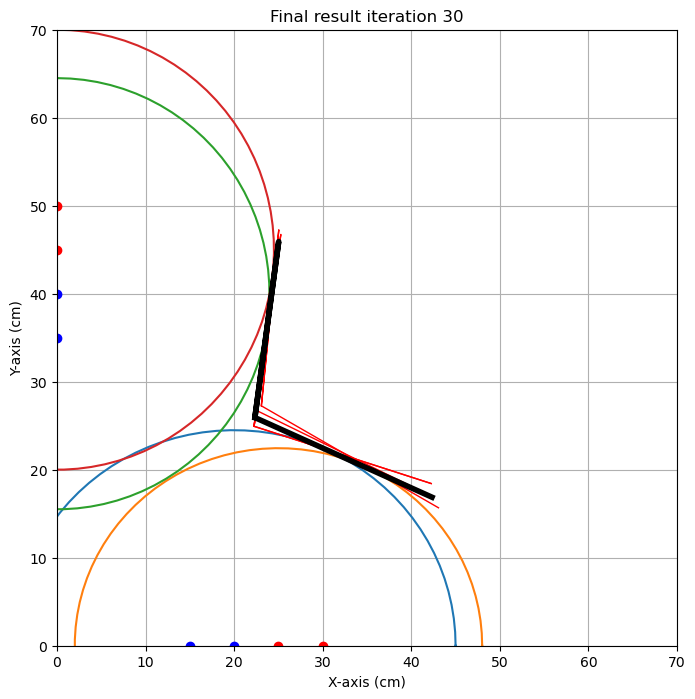

{'alpha': np.float64(-24.34890172595352), 'alpha_eps': 0.0, 'beta': np.float64(7.660275221047165), 'beta_eps': 0.0, 'x0': np.float64(22.337614938470107), 'x0_eps': 0.0, 'y0': np.float64(25.92793590048293), 'y0_eps': 0.0}
Victor
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  40   0  50
1  20   0  30   0  46
2   0  40   0  30  41
3   0  30   0  20  37


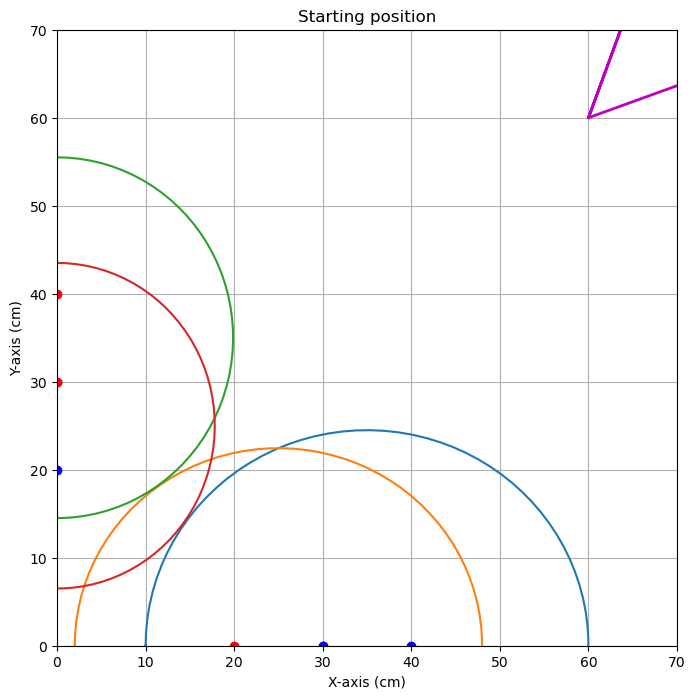


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=98.455


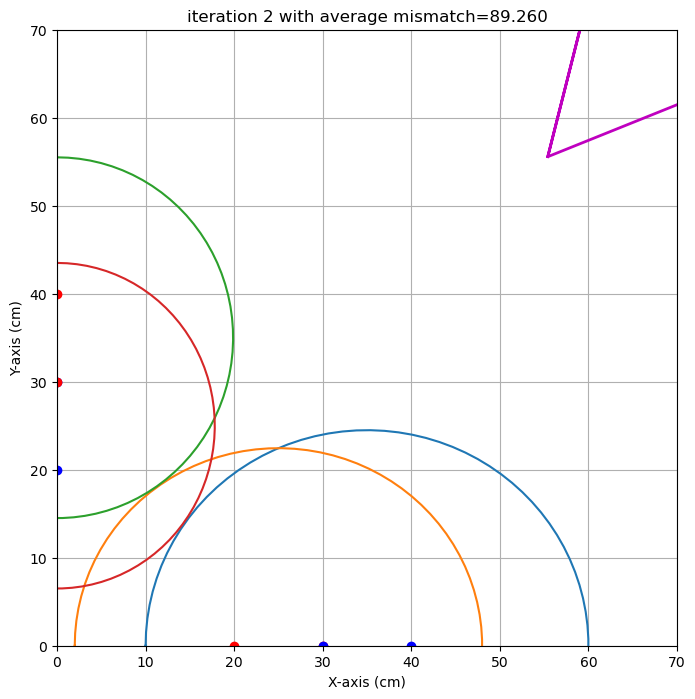

end iteration 2 with average mismatch=89.260


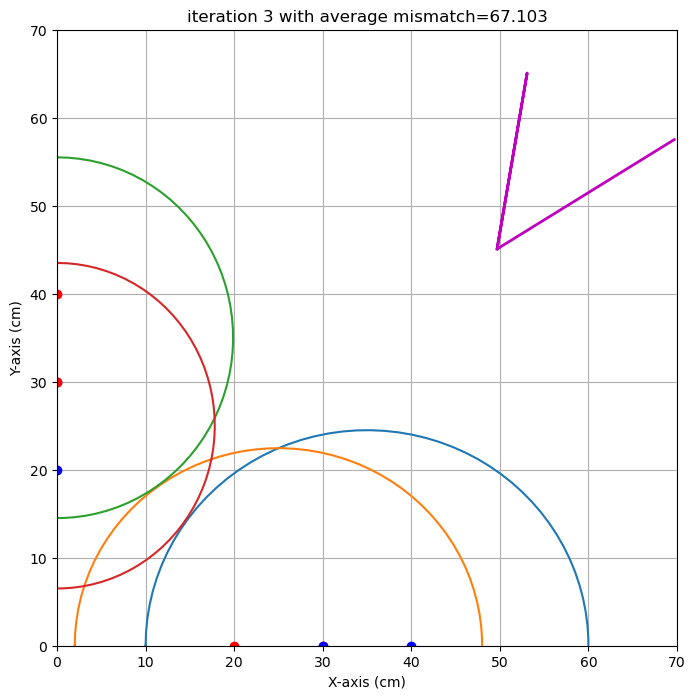

end iteration 3 with average mismatch=67.103


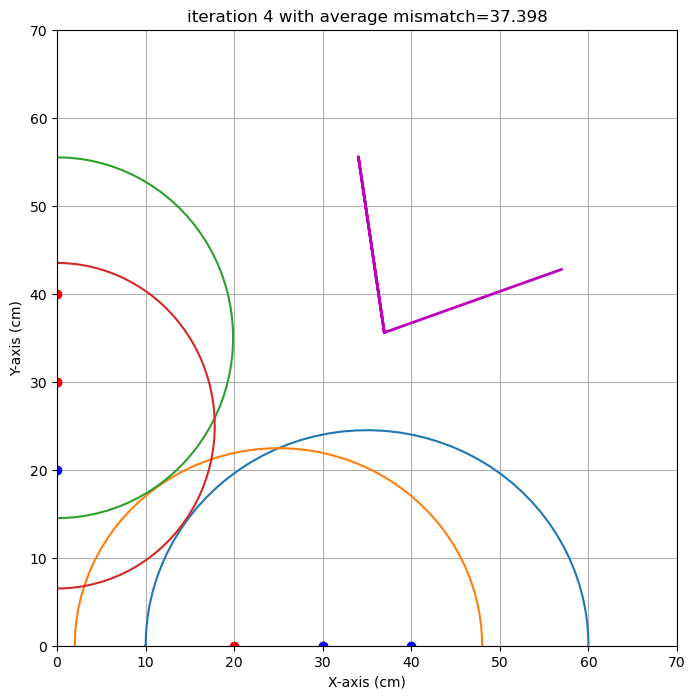

end iteration 4 with average mismatch=37.398


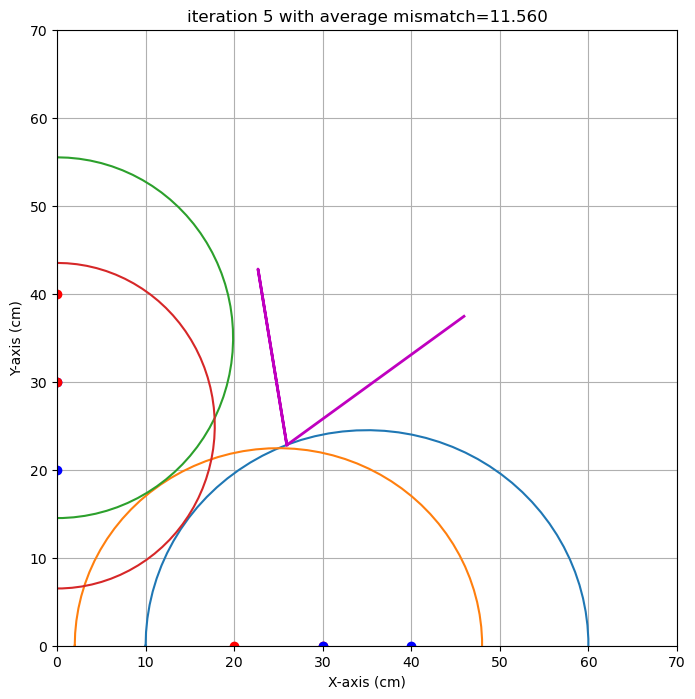

end iteration 5 with average mismatch=11.560


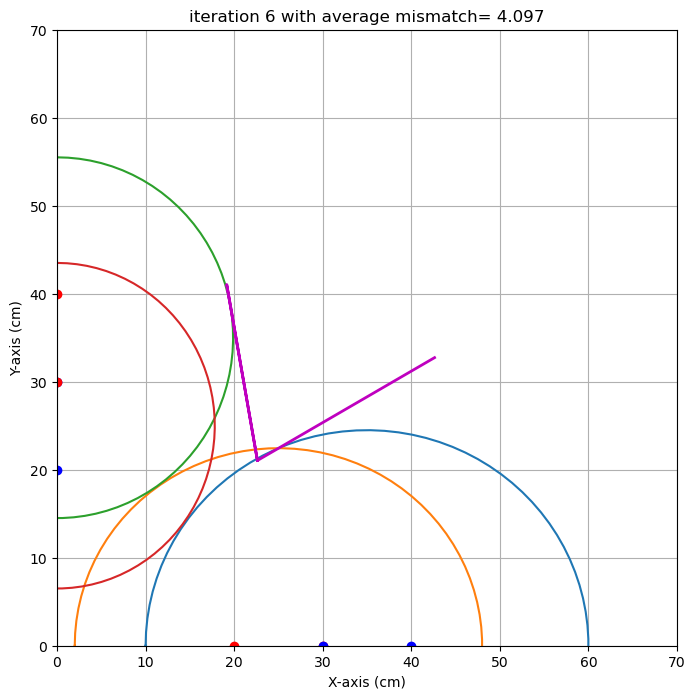

end iteration 6 with average mismatch= 4.097


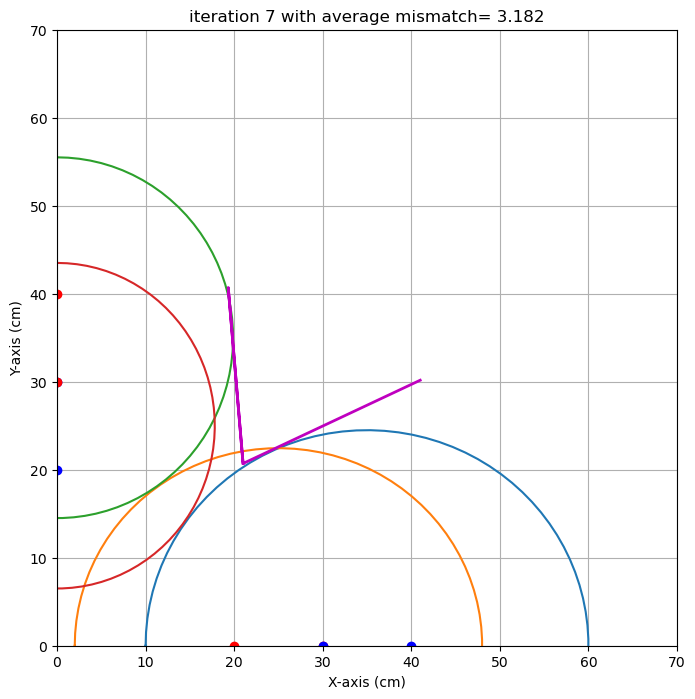

end iteration 7 with average mismatch= 3.182


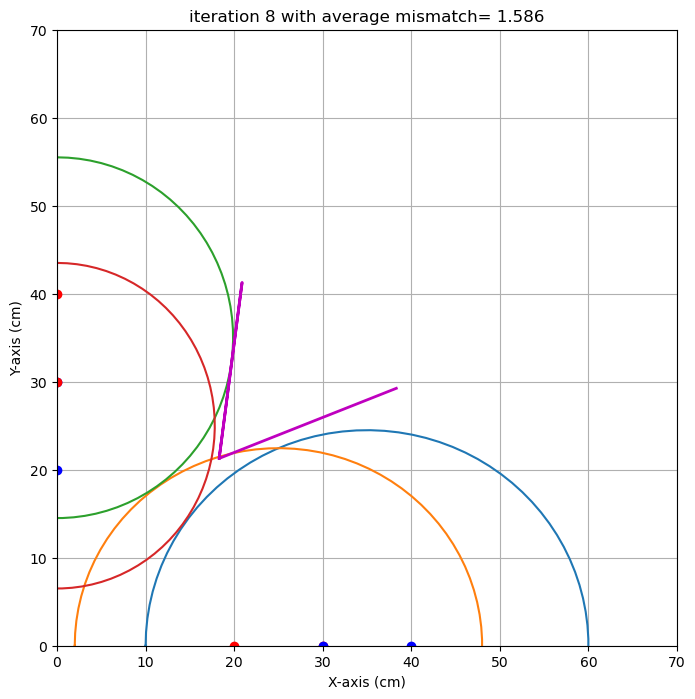

end iteration 8 with average mismatch= 1.586


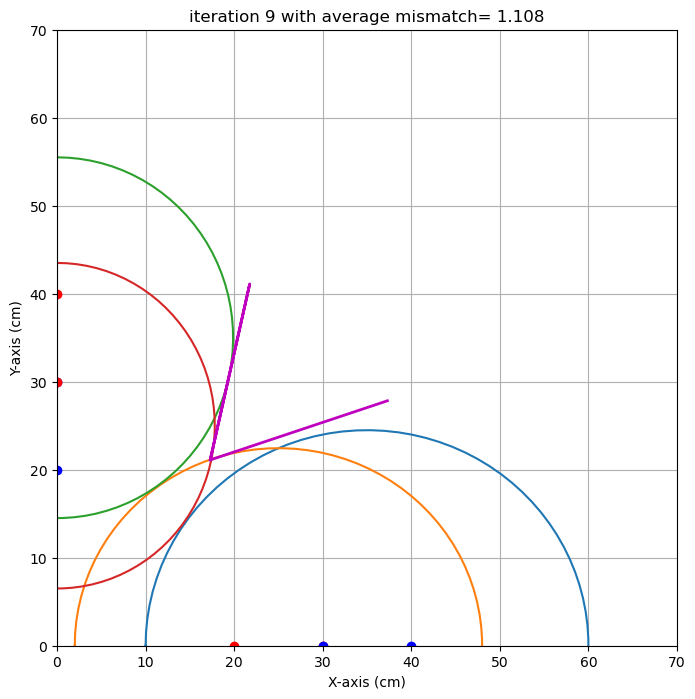

end iteration 9 with average mismatch= 1.108


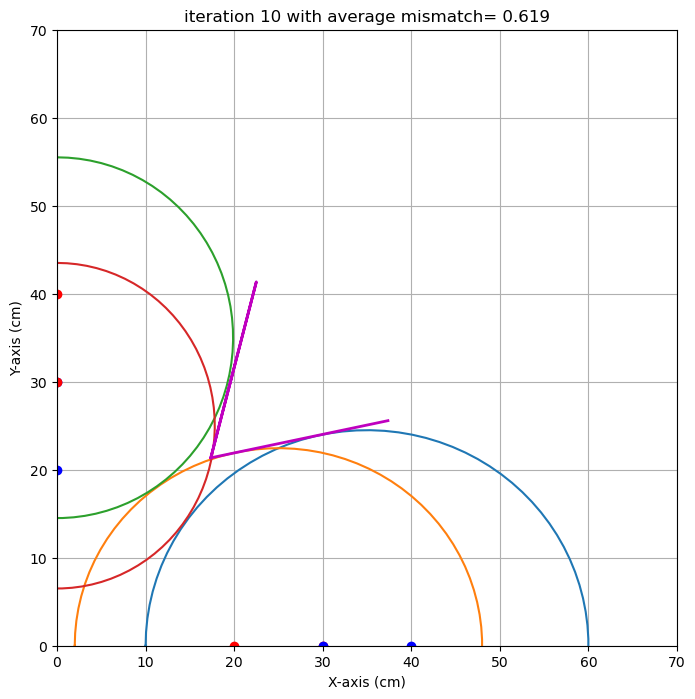

end iteration 10 with average mismatch= 0.619
end iteration 11 with average mismatch= 0.619


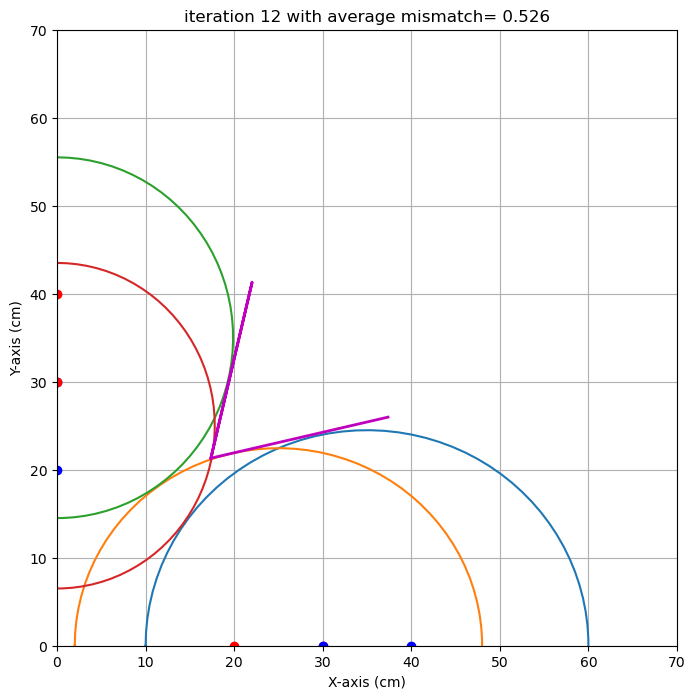

end iteration 12 with average mismatch= 0.526
end iteration 13 with average mismatch= 0.514
end iteration 14 with average mismatch= 0.509
end iteration 15 with average mismatch= 0.508
end iteration 16 with average mismatch= 0.507
end iteration 17 with average mismatch= 0.507
end iteration 18 with average mismatch= 0.507
end iteration 19 with average mismatch= 0.500
end iteration 20 with average mismatch= 0.496
end iteration 21 with average mismatch= 0.496
end iteration 22 with average mismatch= 0.496
end iteration 23 with average mismatch= 0.496
end iteration 24 with average mismatch= 0.496
end iteration 25 with average mismatch= 0.496
end iteration 26 with average mismatch= 0.496
end iteration 27 with average mismatch= 0.496


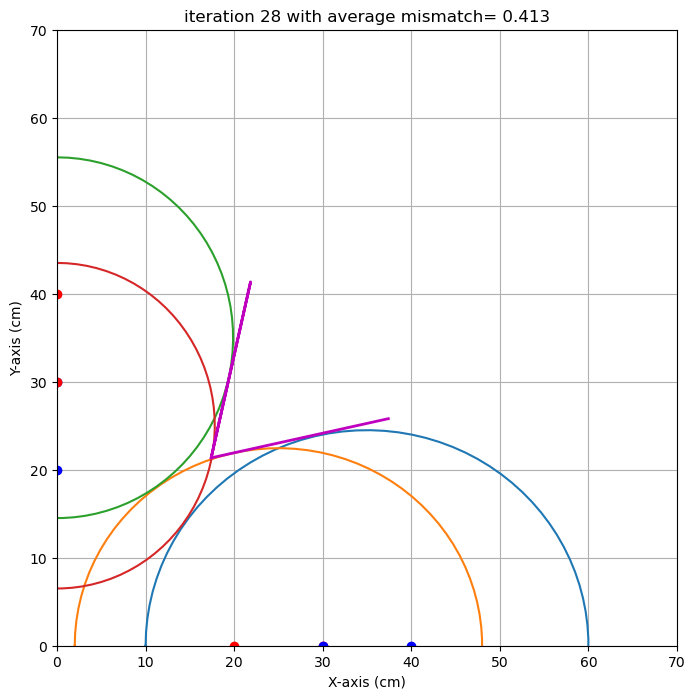

end iteration 28 with average mismatch= 0.413
end iteration 29 with average mismatch= 0.405
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.405
###############################################################################
end of iteration  30
Best alpha=  12.54 with uncertainty=   0.62
Best beta =  12.53 with uncertainty=   0.65
Best x0   =  17.37 with uncertainty=   0.07
Best y0   =  21.31 with uncertainty=   0.14
###############################################################################


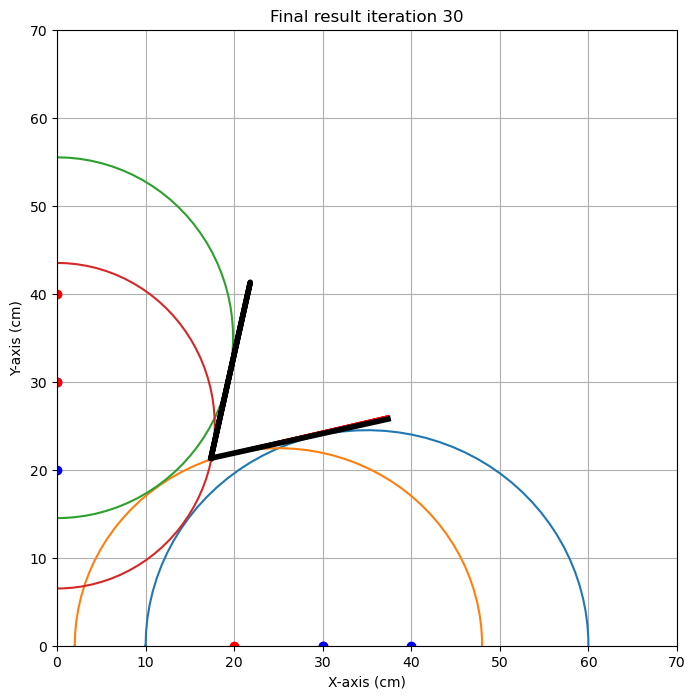

{'alpha': np.float64(12.54183297221581), 'alpha_eps': np.float64(0.6224890277763748), 'beta': np.float64(12.534175966914008), 'beta_eps': np.float64(0.6534794360804703), 'x0': np.float64(17.374082073704336), 'x0_eps': np.float64(0.07432799969880222), 'y0': np.float64(21.30776763434488), 'y0_eps': np.float64(0.14237495390986865)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Ben 
x0 target is : 17.0. Gevonden waarde: 22.3 cm met een standaardafwijking van 0.0 cm 
y0 target is : 18.0. Gevonden waarde: 25.9 cm met een standaardafwijking van 0.0 cm 
alpha target is : 10.0. Gevonden waarde: -24.3 graden met een standaardafwijking van 0.0 graad 
beta target is : 15.0. Gevonden waarde: 7.7 graden met een standaardafwijking van 0.0 graad 

Victor 
x0 target is : 17.0. Gevonden waarde: 17.4 cm met een standaardafwijking van 0.1 cm 
y0 target is : 18.0. Gevonden waarde: 21.3 cm met een standaardafwijking van 0.1 cm 
alpha target is : 10.0. Gevonden waarde: 12.5 graden met een standaardafwijking van 0.6 graad 
beta target is : 15.0. Gevonden waarde: 12.5 graden met een standaardafwijking van 0.7 graad 



## Opdracht 8: Iteratie1 14:50
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](IMG_7912.JPG)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  30   0  100.0
1  30   0  20   0   98.3
2   0  60   0  50   20.0
3   0  70   0  60   22.0


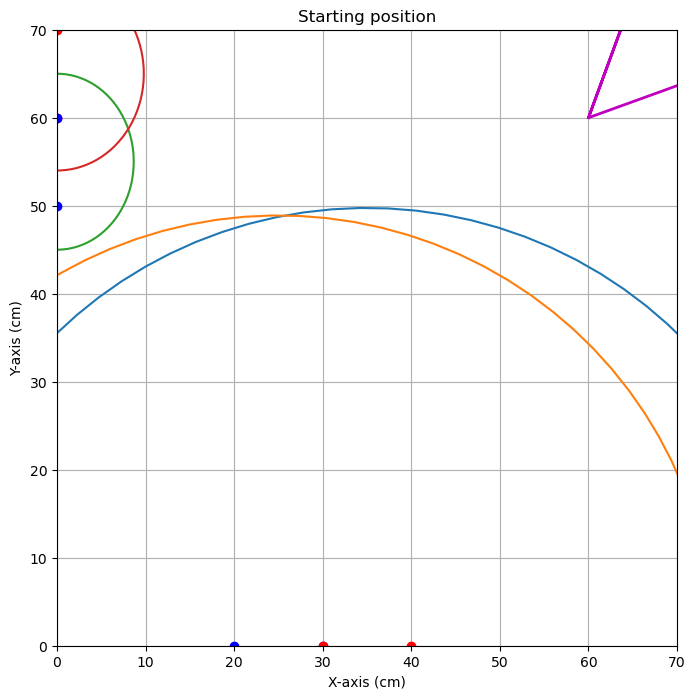


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.890


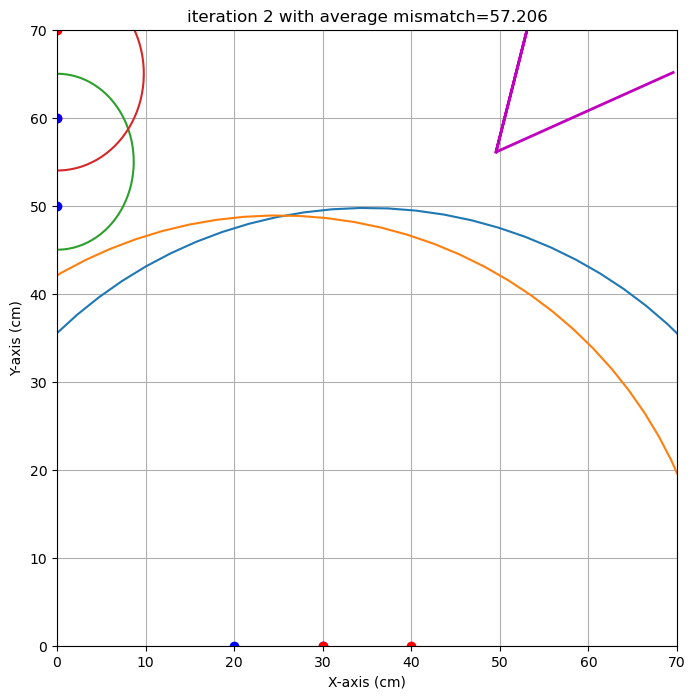

end iteration 2 with average mismatch=57.206


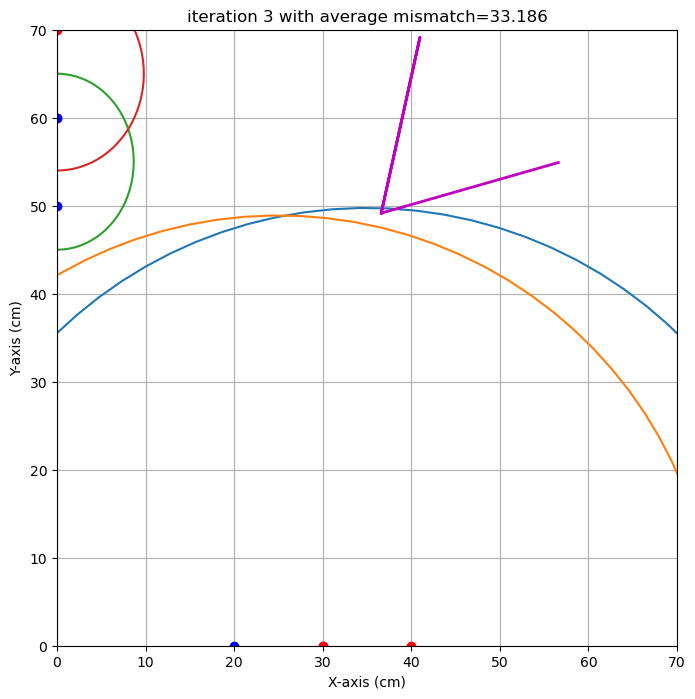

end iteration 3 with average mismatch=33.186


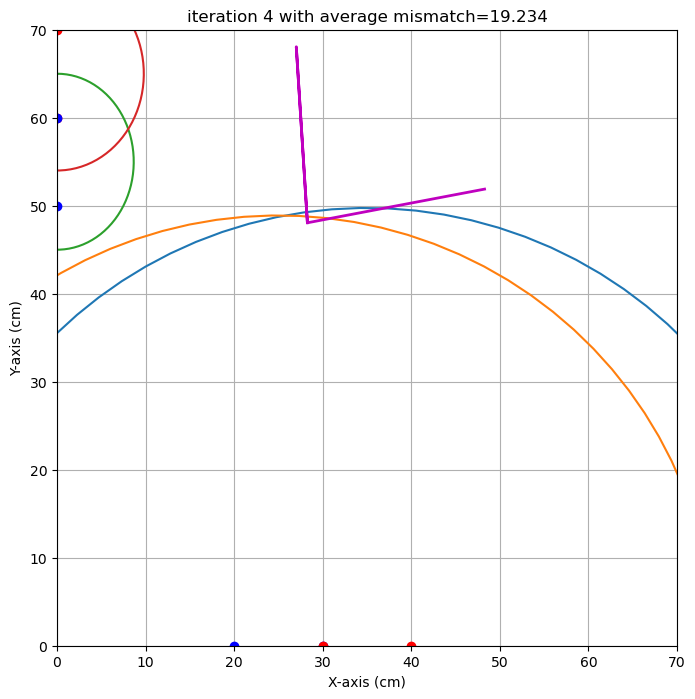

end iteration 4 with average mismatch=19.234


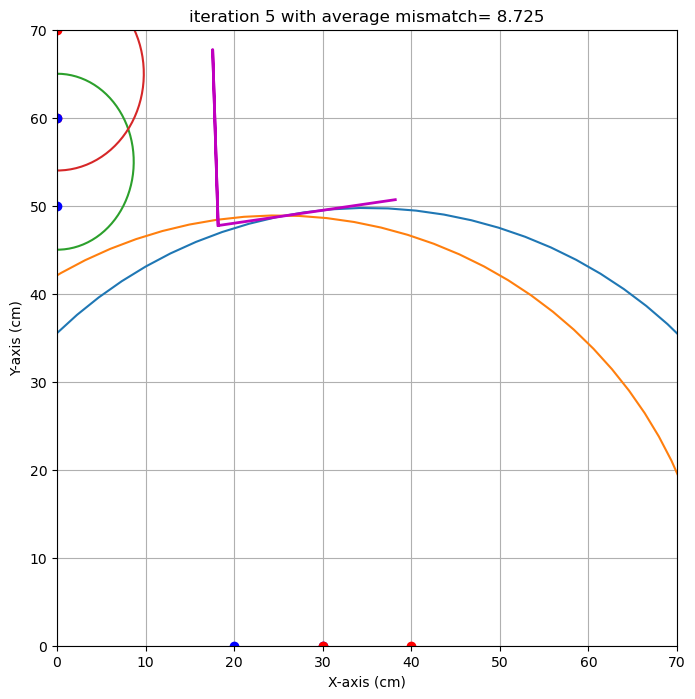

end iteration 5 with average mismatch= 8.725


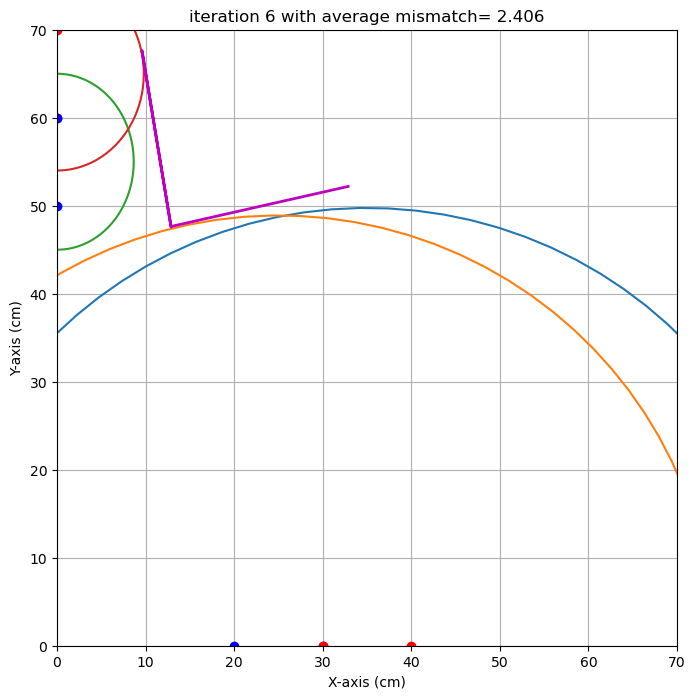

end iteration 6 with average mismatch= 2.406


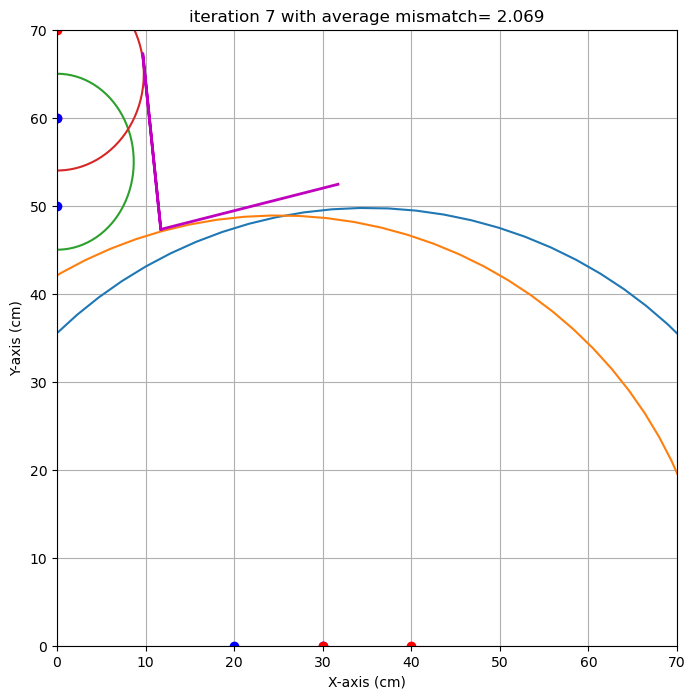

end iteration 7 with average mismatch= 2.069


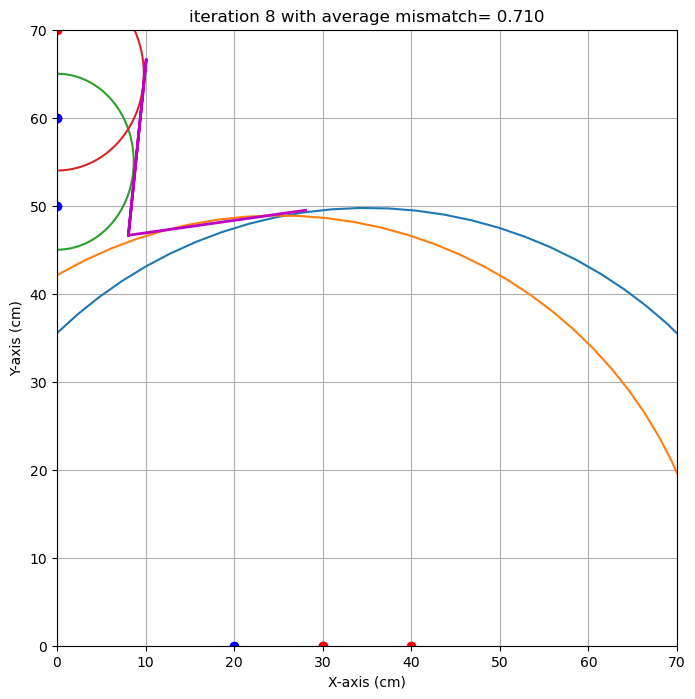

end iteration 8 with average mismatch= 0.710


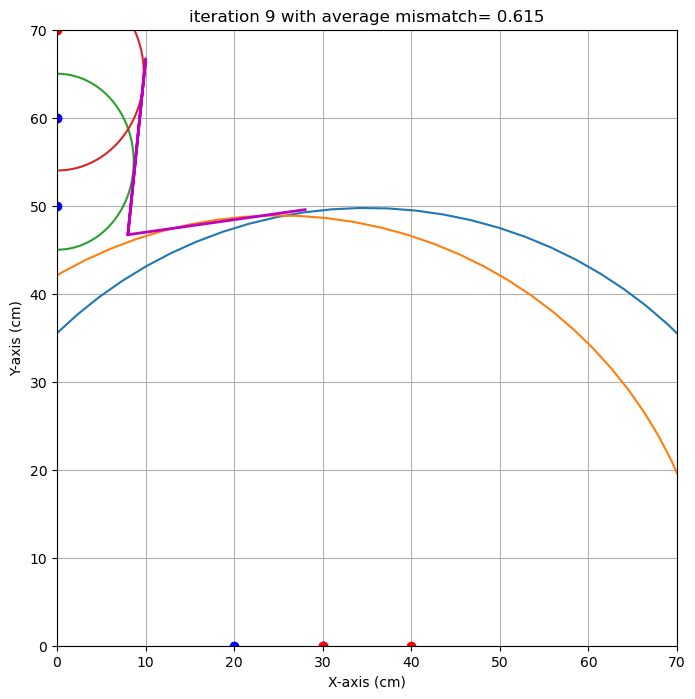

end iteration 9 with average mismatch= 0.615


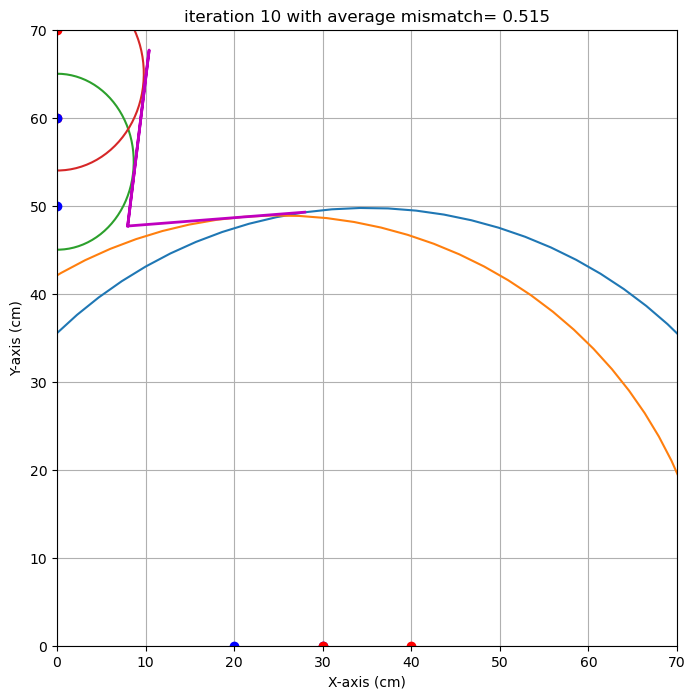

end iteration 10 with average mismatch= 0.515
end iteration 11 with average mismatch= 0.502
end iteration 12 with average mismatch= 0.495
end iteration 13 with average mismatch= 0.451
end iteration 14 with average mismatch= 0.408
end iteration 15 with average mismatch= 0.407
end iteration 16 with average mismatch= 0.407
end iteration 17 with average mismatch= 0.407
end iteration 18 with average mismatch= 0.407
end iteration 19 with average mismatch= 0.407
end iteration 20 with average mismatch= 0.407
end iteration 21 with average mismatch= 0.407
end iteration 22 with average mismatch= 0.407
end iteration 23 with average mismatch= 0.407
end iteration 24 with average mismatch= 0.407
end iteration 25 with average mismatch= 0.407
end iteration 26 with average mismatch= 0.407
end iteration 27 with average mismatch= 0.407
end iteration 28 with average mismatch= 0.407
end iteration 29 with average mismatch= 0.407
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

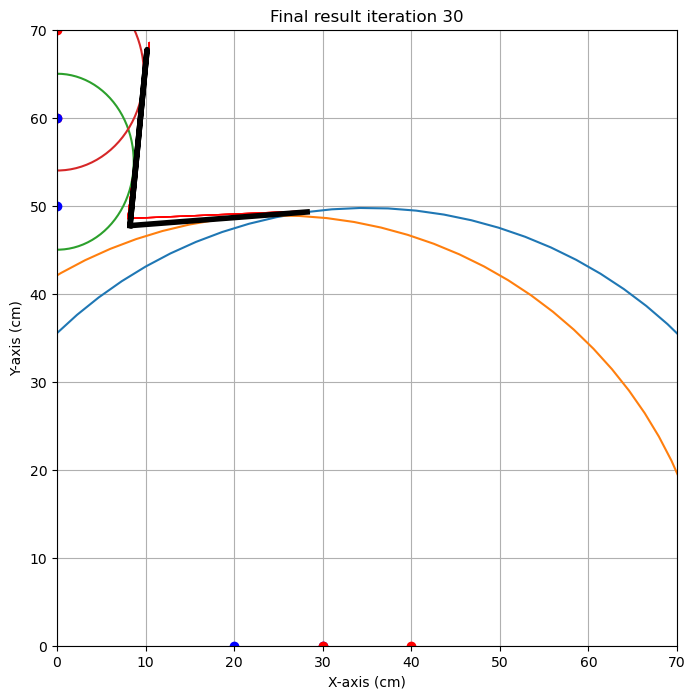

{'alpha': np.float64(4.4330230710178755), 'alpha_eps': np.float64(2.009283296770767), 'beta': np.float64(5.504862044349939), 'beta_eps': np.float64(1.3887179326592287), 'x0': np.float64(8.239067301126187), 'x0_eps': np.float64(0.23569517068117563), 'y0': np.float64(47.739306398268326), 'y0_eps': np.float64(0.8090237830586133)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  20   0  52
1  20   0  10   0  55
2   0  40   0  30  30
3   0  30   0  20  33


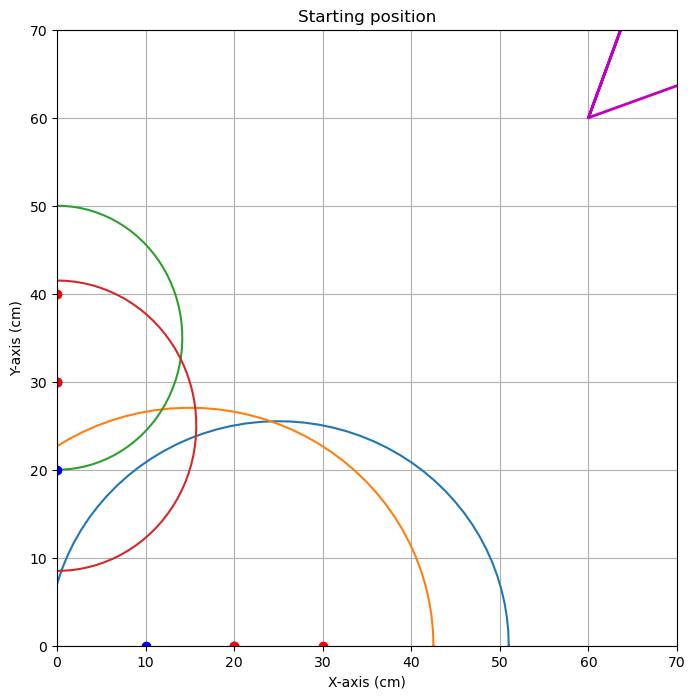


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=104.242


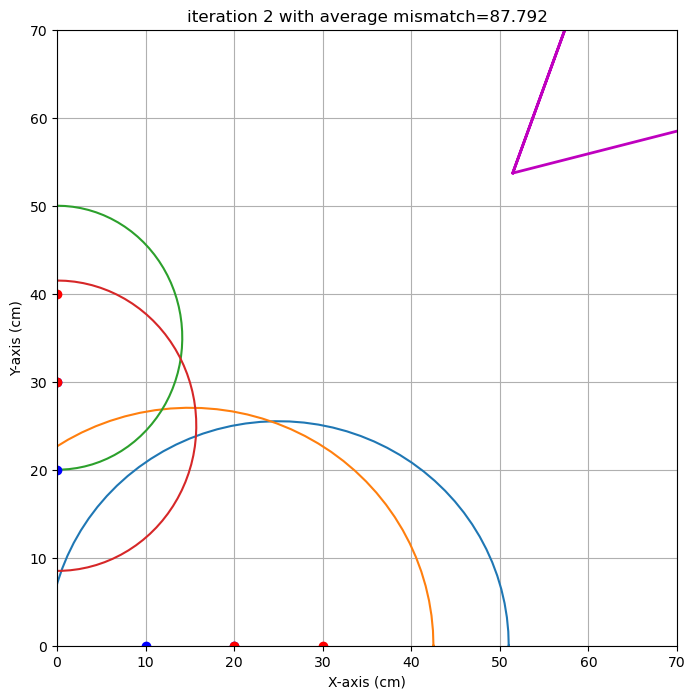

end iteration 2 with average mismatch=87.792


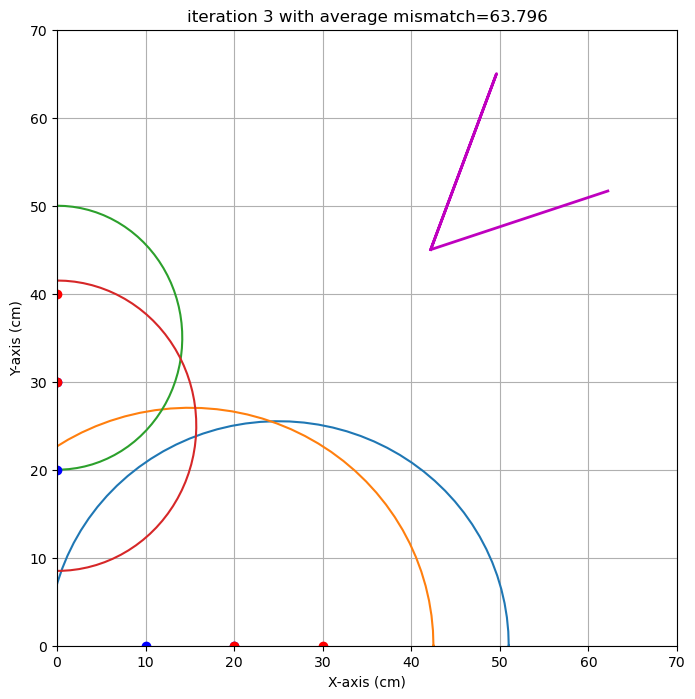

end iteration 3 with average mismatch=63.796


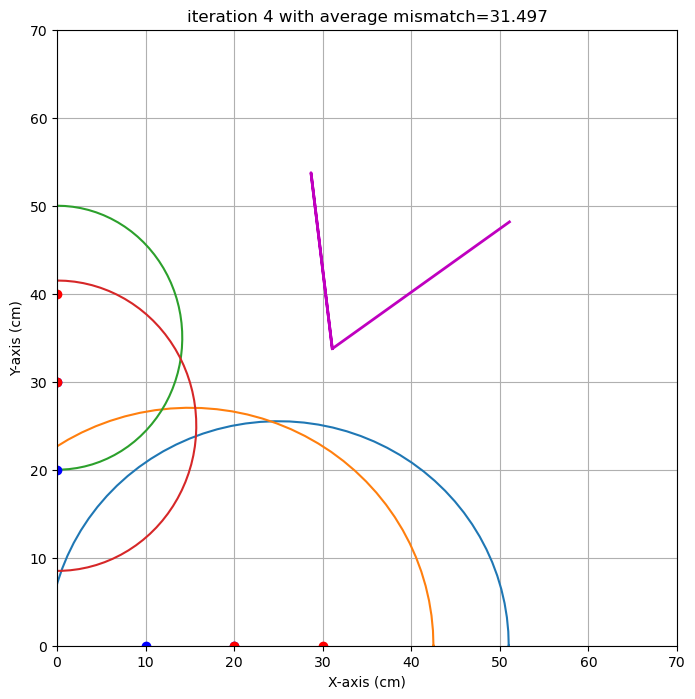

end iteration 4 with average mismatch=31.497


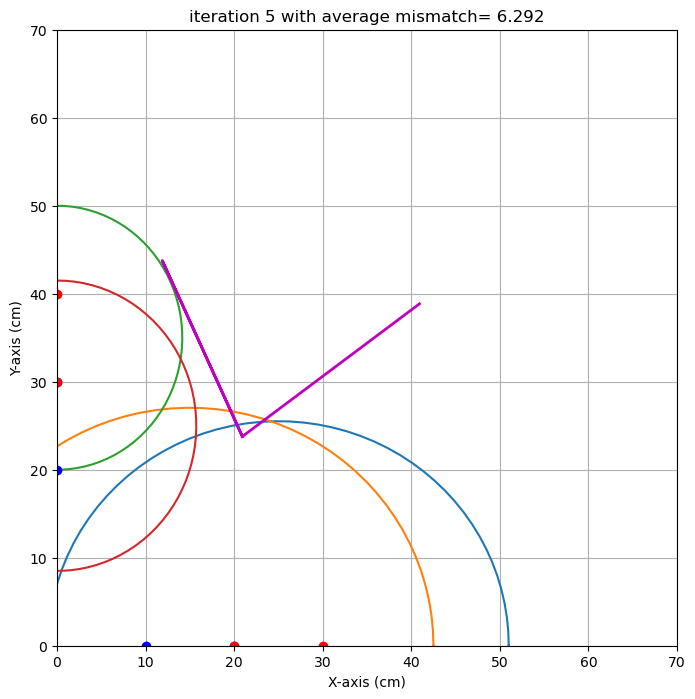

end iteration 5 with average mismatch= 6.292
end iteration 6 with average mismatch= 5.892


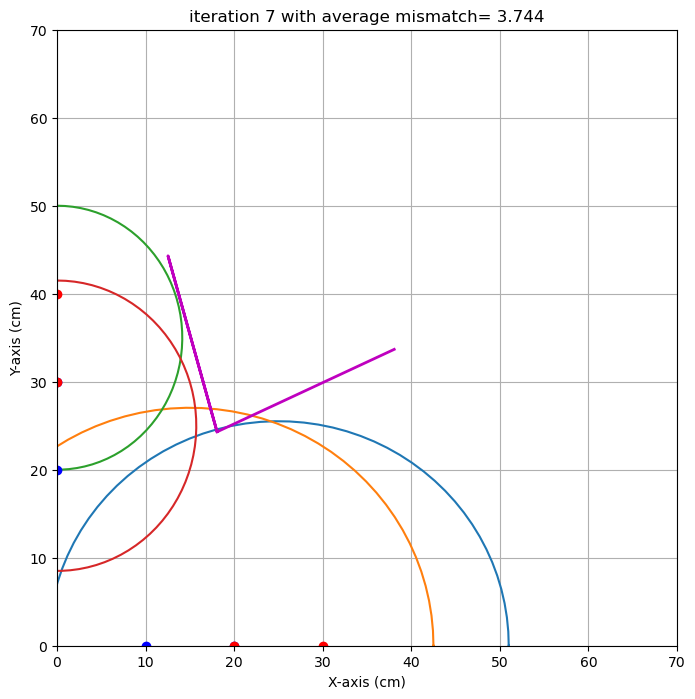

end iteration 7 with average mismatch= 3.744


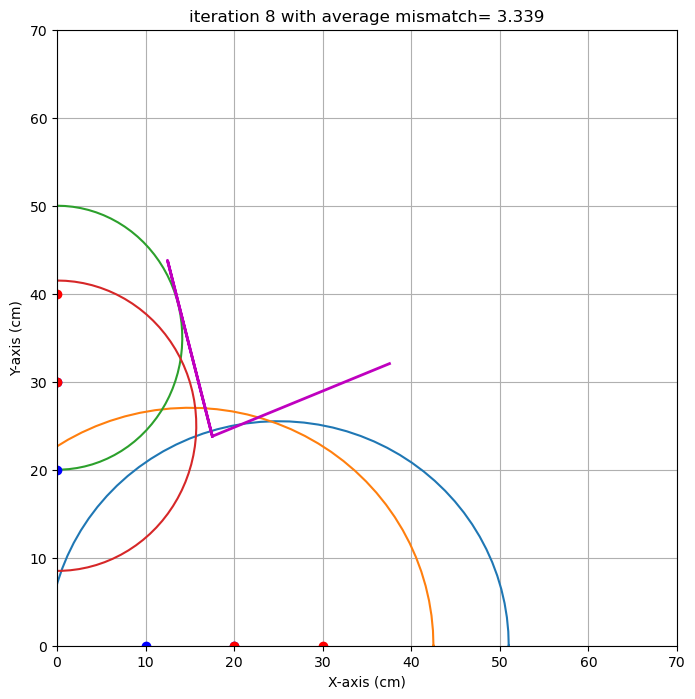

end iteration 8 with average mismatch= 3.339


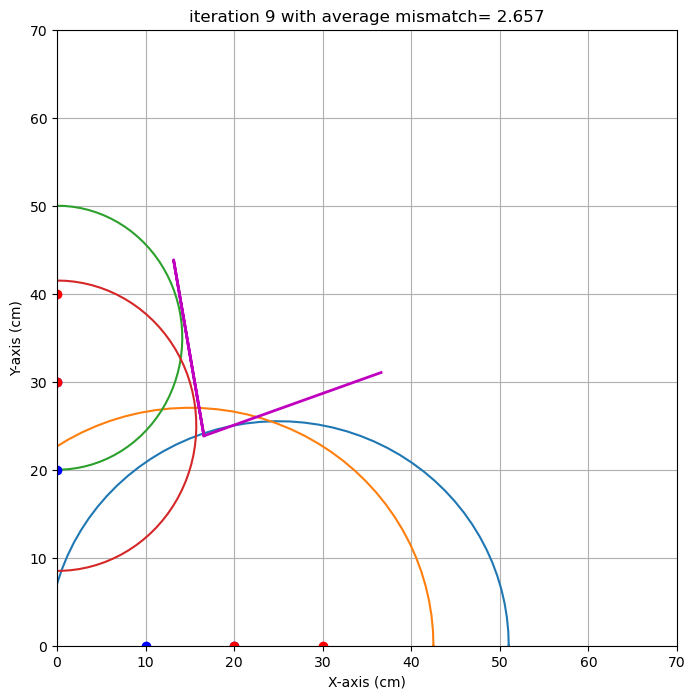

end iteration 9 with average mismatch= 2.657


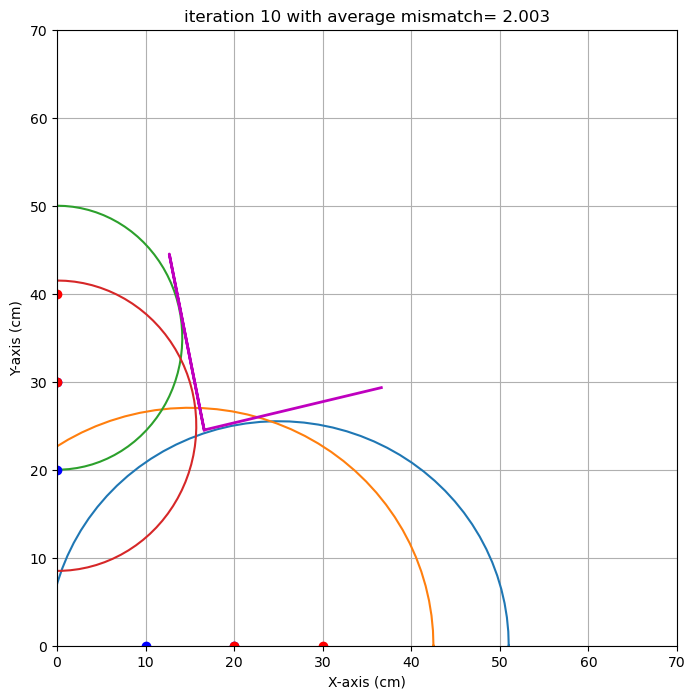

end iteration 10 with average mismatch= 2.003


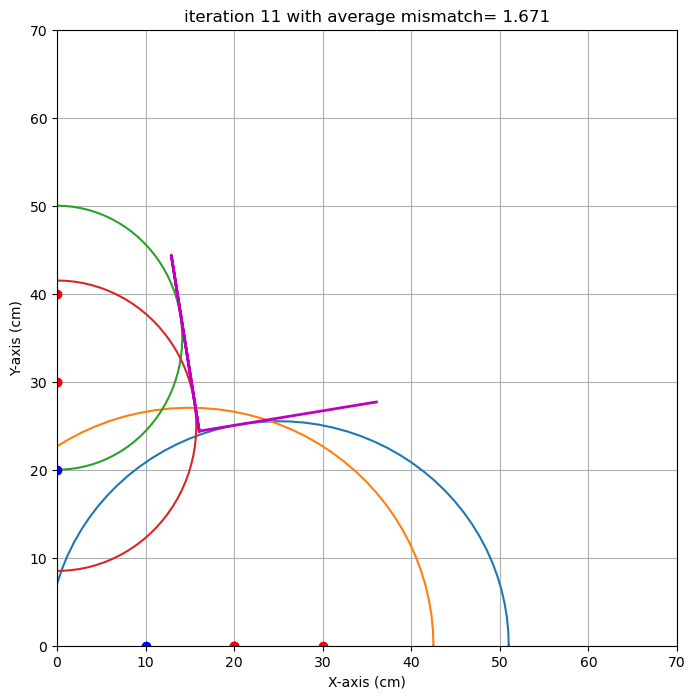

end iteration 11 with average mismatch= 1.671
end iteration 12 with average mismatch= 1.615
end iteration 13 with average mismatch= 1.614
end iteration 14 with average mismatch= 1.613
end iteration 15 with average mismatch= 1.583
end iteration 16 with average mismatch= 1.454
end iteration 17 with average mismatch= 1.452
end iteration 18 with average mismatch= 1.452
end iteration 19 with average mismatch= 1.452


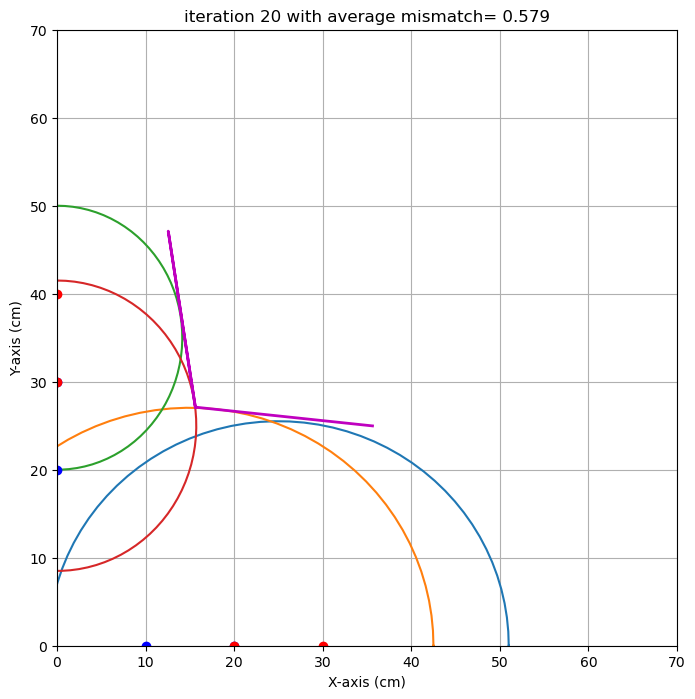

end iteration 20 with average mismatch= 0.579


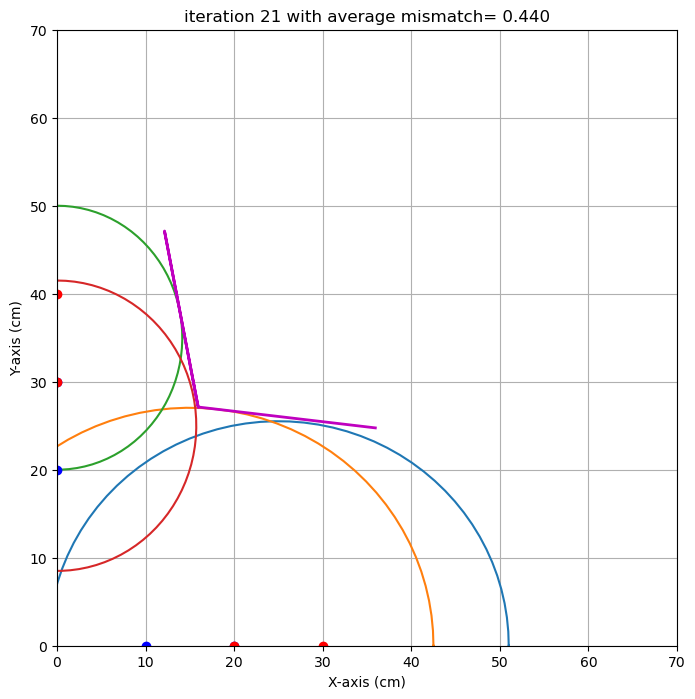

end iteration 21 with average mismatch= 0.440
end iteration 22 with average mismatch= 0.424
end iteration 23 with average mismatch= 0.406
end iteration 24 with average mismatch= 0.372
end iteration 25 with average mismatch= 0.359


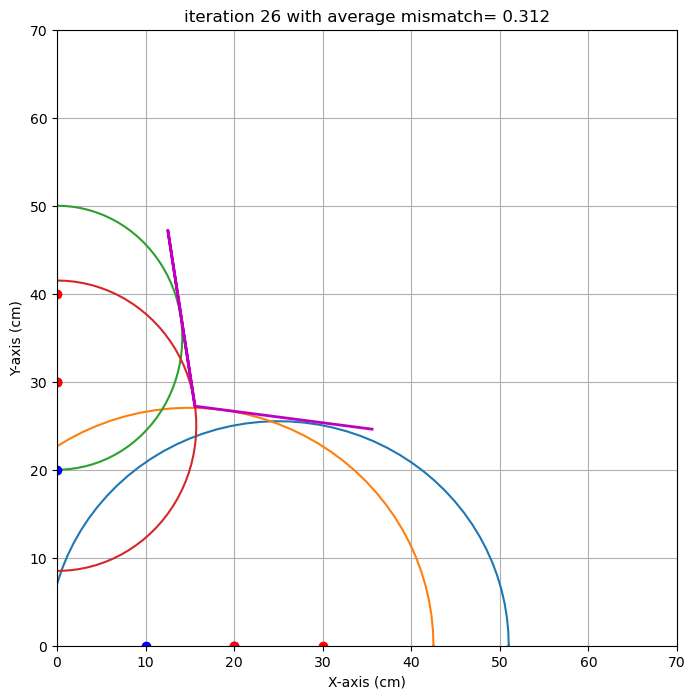

end iteration 26 with average mismatch= 0.312
end iteration 27 with average mismatch= 0.298
end iteration 28 with average mismatch= 0.296
end iteration 29 with average mismatch= 0.296
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.296
###############################################################################
end of iteration  30
Best alpha=  -7.45 with uncertainty=   3.21
Best beta =  -8.71 with uncertainty=   5.33
Best x0   =  15.55 with uncertainty=   1.05
Best y0   =  27.20 with uncertainty=   0.41
###############################################################################


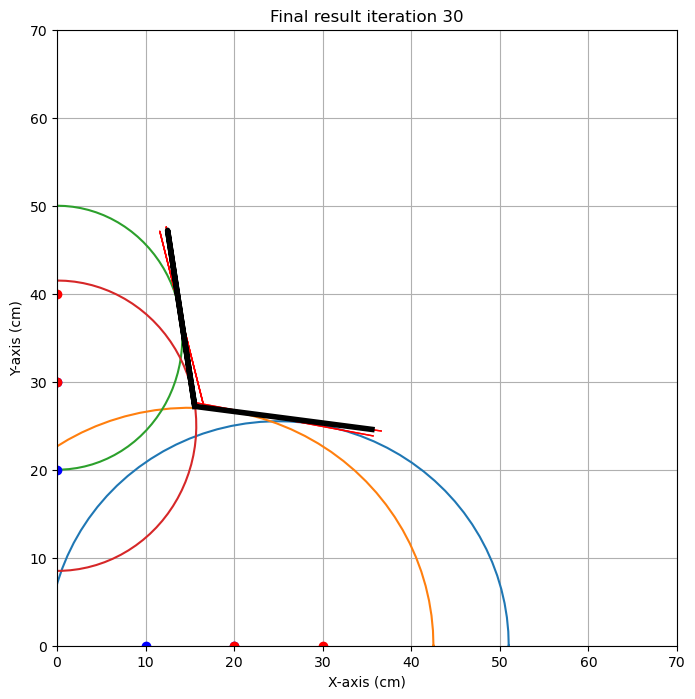

{'alpha': np.float64(-7.454573147265445), 'alpha_eps': np.float64(3.208808950795917), 'beta': np.float64(-8.70573353686468), 'beta_eps': np.float64(5.325387776692827), 'x0': np.float64(15.547907121214388), 'x0_eps': np.float64(1.0507209563717996), 'y0': np.float64(27.200577036513653), 'y0_eps': np.float64(0.40953102321502044)}
locatie 1 
x0 target is : 7.0. Gevonden waarde: 8.2 cm met een standaardafwijking van 0.2 cm 
y0 target is : 47.0. Gevonden waarde: 47.7 cm met een standaardafwijking van 0.8 cm 
alpha target is : 3.0. Gevonden waarde: 4.4 graden met een standaardafwijking van 2.0 graad 
beta target is : 8.0. Gevonden waarde: 5.5 graden met een standaardafwijking van 1.4 graad 

locatie 2 
x0 target is : 13.0. Gevonden waarde: 15.5 cm met een standaardafwijking van 1.1 cm 
y0 target is : 25.0. Gevonden waarde: 27.2 cm met een standaardafwijking van 0.4 cm 
alpha target is : -5.0. Gevonden waarde: -7.5 graden met een standaardafwijking van 3.2 graad 
beta target is : 6.0. Gevonden

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 7,
                    'y0': 47,
                    'alpha' : 3,
                    'beta' : 8,},
           'locatie 2':{'x0': 13,
                    'y0': 25,
                    'alpha' : -5,
                    'beta' : 6,}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 30, 0, 100],
    [30, 0, 20, 0, 98.3],
    #[0, 40, 0, 30, niet geldig],
    #[0, 30, 0, 20, niet geldig],
    #[0, 20, 0, 10, niet geldig],
    #[0, 50, 0, 40, niet geldig],
    [0, 60, 0, 50, 20],
    [0, 70, 0, 60, 22]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40, 0, 30, 0, niet geldig],
    [30, 0, 20, 0, 52],
    [20, 0, 10, 0, 55],
    [0, 40, 0, 30, 30],
    [0, 30, 0, 20, 33]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  30   0  80.0
1  30   0  20   0  85.4
2   0  40   0  30  66.3
3   0  50   0  40  61.0


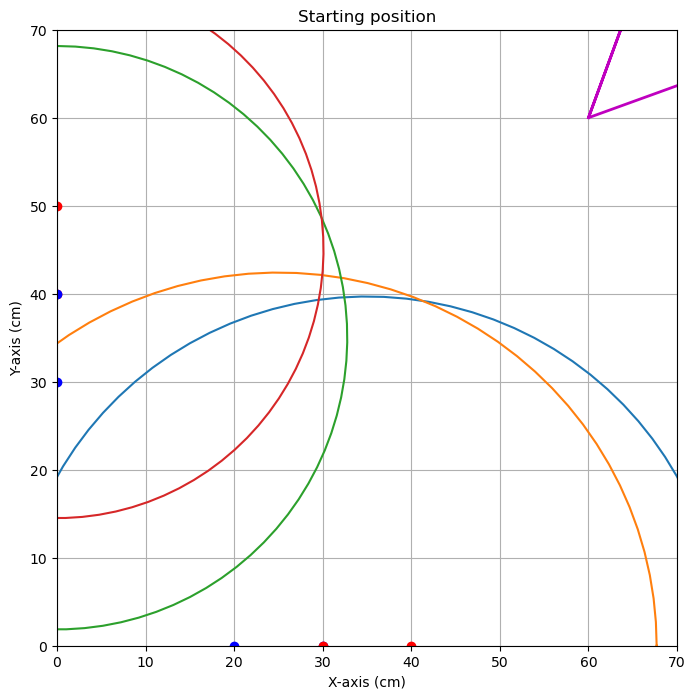


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.439


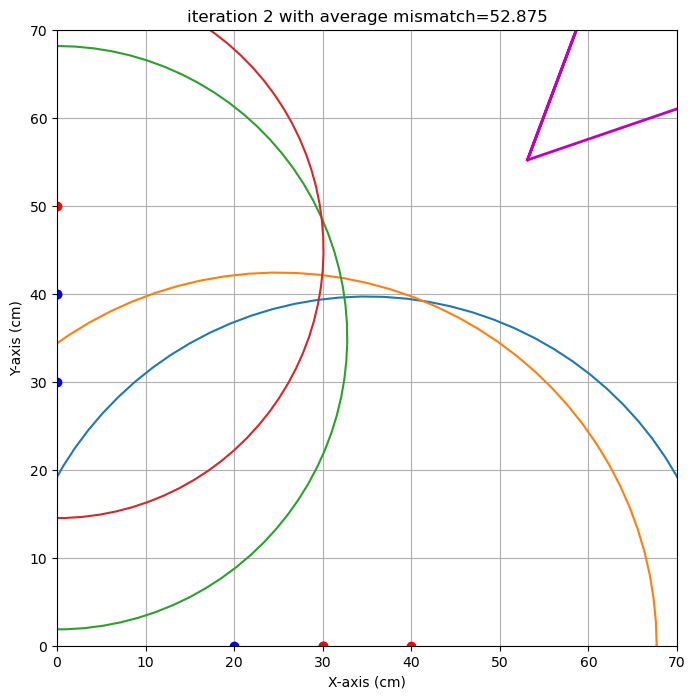

end iteration 2 with average mismatch=52.875


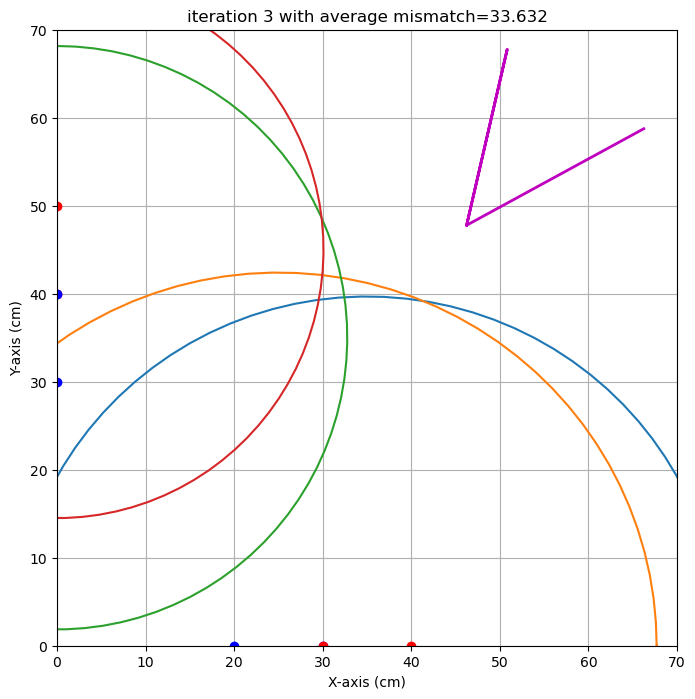

end iteration 3 with average mismatch=33.632


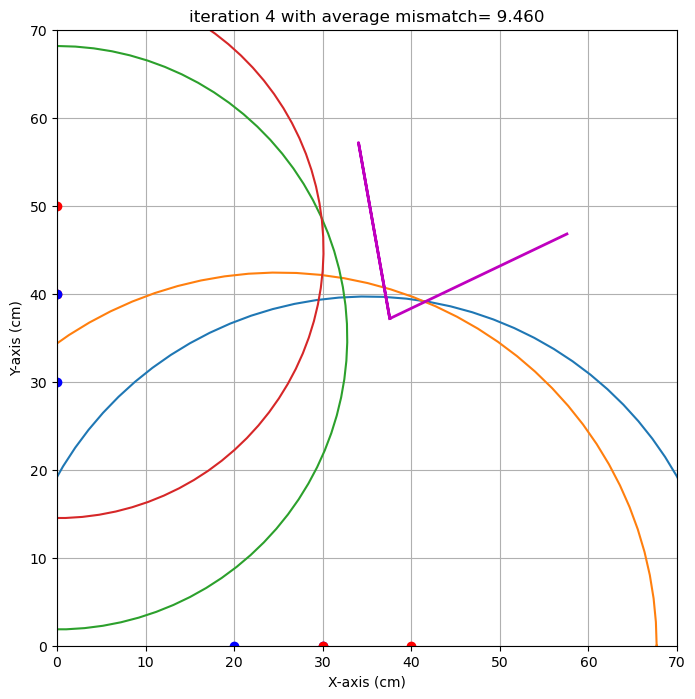

end iteration 4 with average mismatch= 9.460


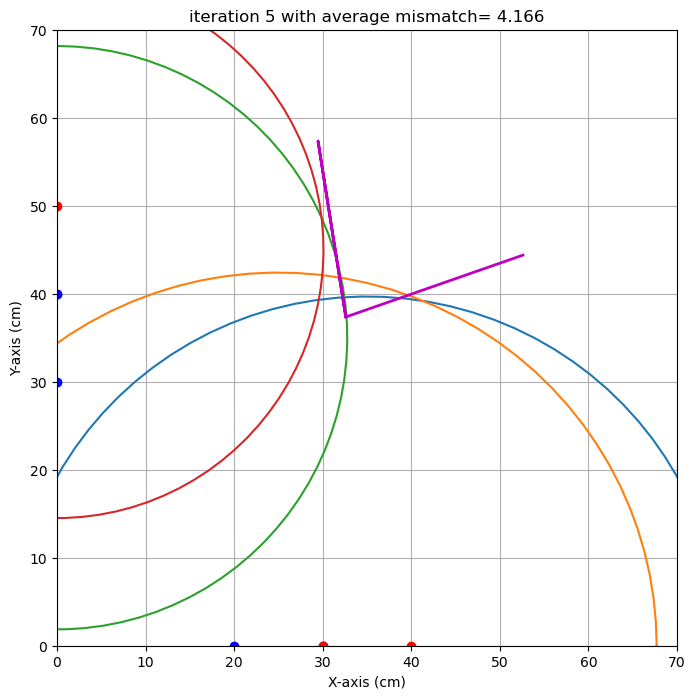

end iteration 5 with average mismatch= 4.166


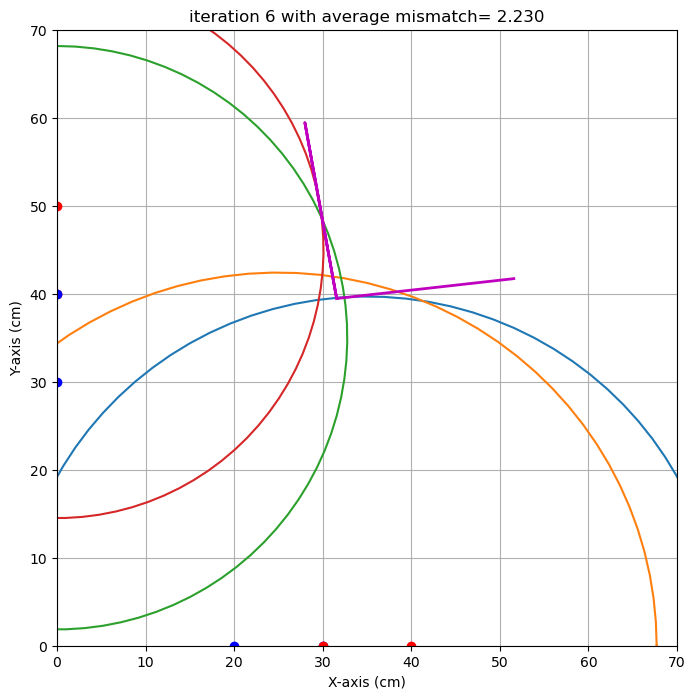

end iteration 6 with average mismatch= 2.230


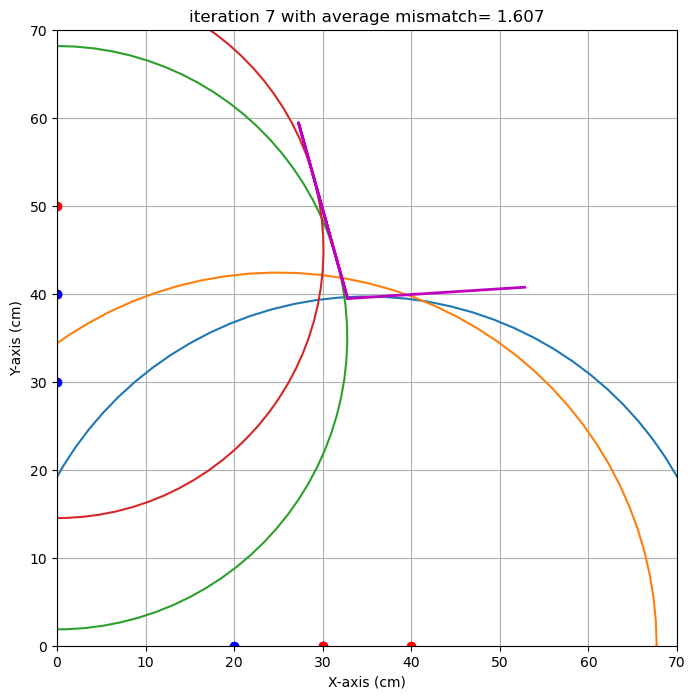

end iteration 7 with average mismatch= 1.607
end iteration 8 with average mismatch= 1.599
end iteration 9 with average mismatch= 1.581


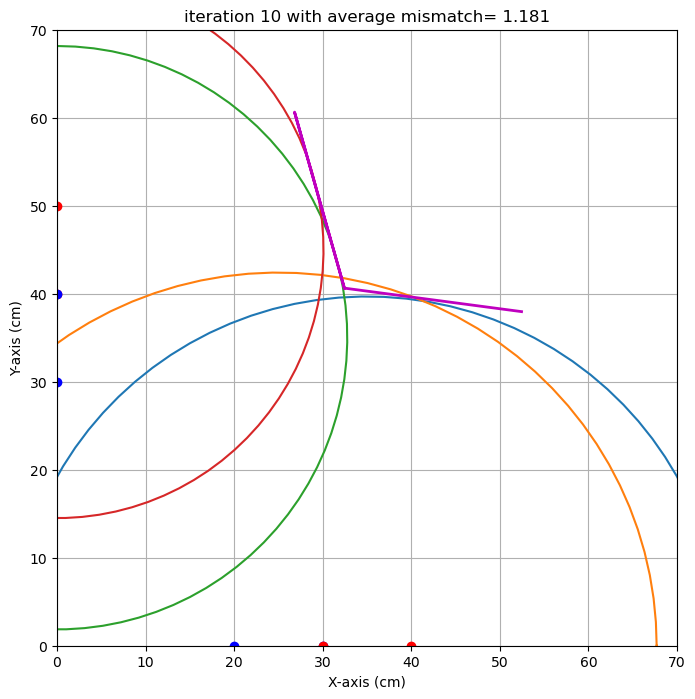

end iteration 10 with average mismatch= 1.181


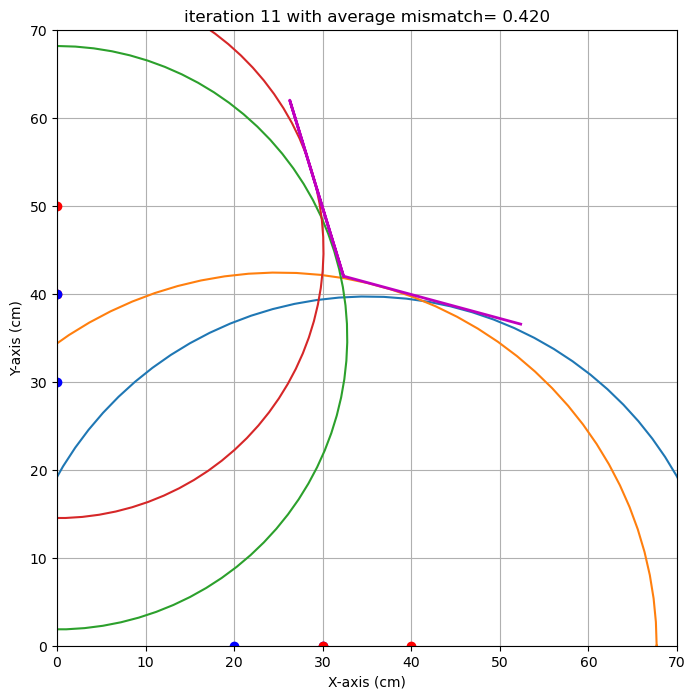

end iteration 11 with average mismatch= 0.420


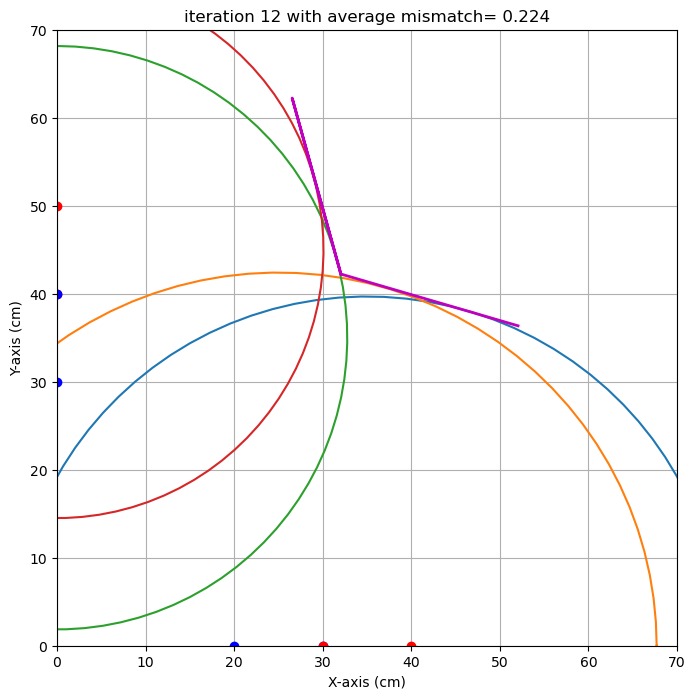

end iteration 12 with average mismatch= 0.224
end iteration 13 with average mismatch= 0.220
end iteration 14 with average mismatch= 0.212
end iteration 15 with average mismatch= 0.209
end iteration 16 with average mismatch= 0.209
end iteration 17 with average mismatch= 0.209
end iteration 18 with average mismatch= 0.209
end iteration 19 with average mismatch= 0.209
end iteration 20 with average mismatch= 0.209
end iteration 21 with average mismatch= 0.209
end iteration 22 with average mismatch= 0.209
end iteration 23 with average mismatch= 0.209
end iteration 24 with average mismatch= 0.209
end iteration 25 with average mismatch= 0.209
end iteration 26 with average mismatch= 0.209
end iteration 27 with average mismatch= 0.209
end iteration 28 with average mismatch= 0.209
end iteration 29 with average mismatch= 0.209
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.209
#################

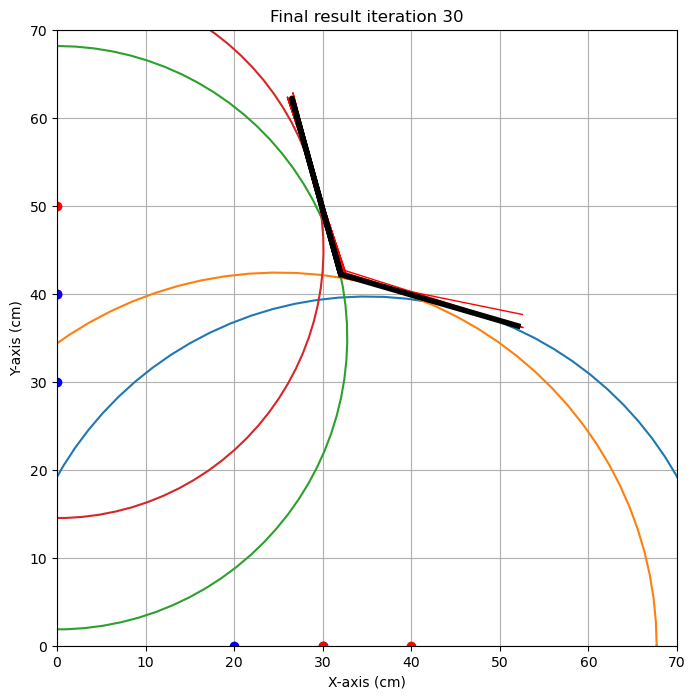

{'alpha': np.float64(-16.334816706035546), 'alpha_eps': np.float64(4.719361474434228), 'beta': np.float64(-15.433546933122402), 'beta_eps': np.float64(2.7592900560199336), 'x0': np.float64(32.030717532286275), 'x0_eps': np.float64(0.5529740769070557), 'y0': np.float64(42.204789959030826), 'y0_eps': np.float64(0.6314764232705414)}
test locatie 
x0 target is : 32.5. Gevonden waarde: 32.0 cm met een standaardafwijking van 0.6 cm 
y0 target is : 41.0. Gevonden waarde: 42.2 cm met een standaardafwijking van 0.6 cm 
alpha target is : -18.0. Gevonden waarde: -16.3 graden met een standaardafwijking van 4.7 graad 
beta target is : -16.0. Gevonden waarde: -15.4 graden met een standaardafwijking van 2.8 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 32.5,
                    'y0':  41,
                    'alpha' :  -18,
                    'beta' :  -16,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40, 0, 30, 0 , 80],
                    [30, 0, 20, 0, 85.4],
                    [0, 40, 0, 30, 66.3],
                    #[0, 30, 0, 20, niet geldig],
                    [0, 50, 0, 40, 61],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
# 13:45
Figuur: ![Alt](IMG_7906.JPG "Eerste Iteratie")
De zogenaamde "if"-statements waren niet goed gedefineerd, en er was niet goed gedefineerd dat er twee metingen aan het begin gemaakt moesten worden. 

# 14:30
Figuur: ![Alt](IMG_7909.JPG "Tweede Iteratie")
Hadden door dat we niet goed genoeg uitgelegd hadden wanneer we een meting maakten en toch niet verbaal goed genoeg uitgelegd hadden hoe alles werkte. Alleen maar syntax verbeteringen. Hierbij hebben we ook nog de edge cases verbeterd.

Figuur: ![Alt](IMG_7912.JPG "Derde Iteratie")
Compleet afgemaakt, puntjes op de i gezet. En verbeterd waar nodig was, maar bijna hetzelfde als de tweede iteratie.